# **Series de Tiempo — Fronteras**

## **Setup**

In [1]:
# Librerías
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import boxcox

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuraciones
warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Rutas y constantes
RAIZ = Path.cwd().parents[1] if Path.cwd().name == "series" else Path.cwd()
RUTA_TRAIN = RAIZ / "datos" / "processed" / "entrenamiento.csv"
RUTA_TEST = RAIZ / "datos" / "processed" / "prueba.csv"

PERIODO = 12  # estacionalidad mensual

print("Setup completado")


Setup completado


## **Distribución de los datos en las tres fronteras**

Se rankean las fronteras por total acumulado de viajeros (train + test) usando la variable `Frontera`. Las tres principales son 01 La Aurora, 07 Valle Nuevo y 09 San Cristóbal, con una brecha clara frente a la siguiente (08 Pedro de Alvarado). Con estas tres se construyen las series.

In [2]:
# Ranking de fronteras por total de viajeros acumulado en todo el período (train + test).
entrenamiento = pd.read_csv(RUTA_TRAIN, parse_dates=["Fecha"])
prueba = pd.read_csv(RUTA_TEST, parse_dates=["Fecha"])
periodo_completo = pd.concat([entrenamiento, prueba], ignore_index=True)

ranking_fronteras = (
    periodo_completo.groupby("Frontera")["Viajero"].sum()
    .sort_values(ascending=False)
    .round(0)
    .to_frame("viajeros_acumulados")
)
ranking_fronteras.head(5)


,viajeros_acumulados
Frontera,
01 La Aurora,18989985.0
07 Valle Nuevo,10143045.0
09 San Cristóbal,4183632.0
08 Pedro de Alvarado,3764229.0
10 La Ermita (Nueva Anguiatú),2587072.0


## **01 La Aurora**

#### **a. Especifique Inicio, fin, y frecuencia.**

Entrenamiento: enero 2009 a marzo 2021, mensual, 147 observaciones.

In [3]:
# Serie mensual de La Aurora (a partir del conjunto de entrenamiento).
serie_aurora = (
    entrenamiento[entrenamiento["Frontera"] == "01 La Aurora"]
    .groupby("Fecha")["Viajero"].sum()
    .asfreq("MS")
)

# a) Inicio, fin y frecuencia de la serie.
print("Inicio       :", serie_aurora.index.min().date())
print("Fin          :", serie_aurora.index.max().date())
print("Frecuencia   :", serie_aurora.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_aurora.shape[0])


Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

La Aurora (aeropuerto internacional) es la frontera con más flujo de las tres. Se ve crecimiento sostenido 2009-2019 y caída abrupta en 2020 por la pandemia. La amplitud de las oscilaciones anuales crece con el nivel, indicio de varianza no constante.

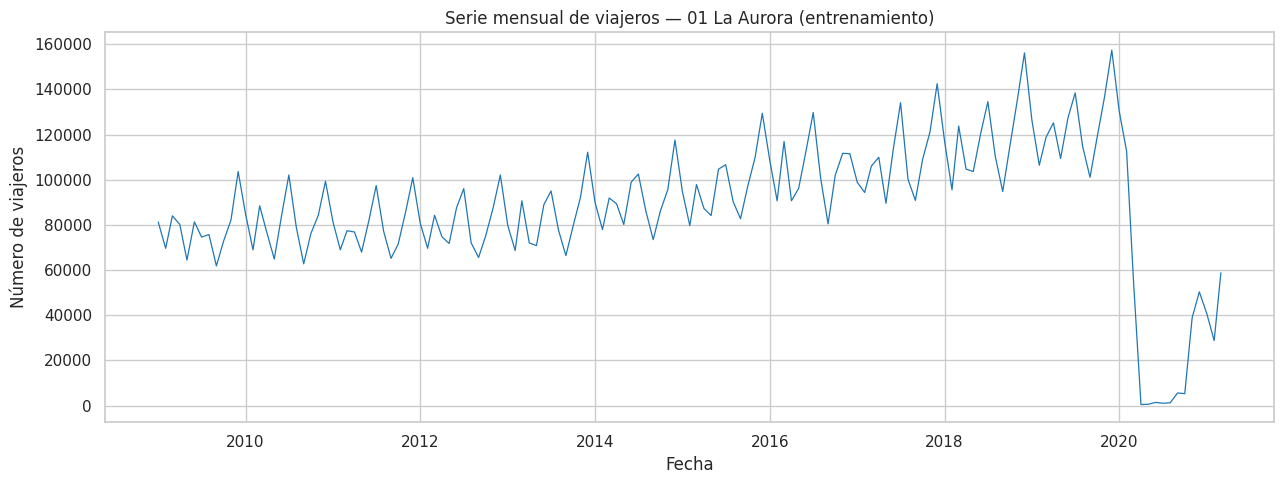

In [4]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_aurora.index, serie_aurora.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual de viajeros — 01 La Aurora (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()


#### **c. Descomponga la serie.**

La descomposición multiplicativa es más adecuada: residuo aditivo std=10,887 (unidades originales) vs. residuo multiplicativo std=0.2173 (relativo, más estable). La tendencia confirma crecimiento 2009-2019 y desplome en 2020; hay estacionalidad clara. Media y desviación móviles no son constantes (suben con los años y colapsan en la pandemia), por lo que la serie no es estacionaria ni en media ni en varianza.

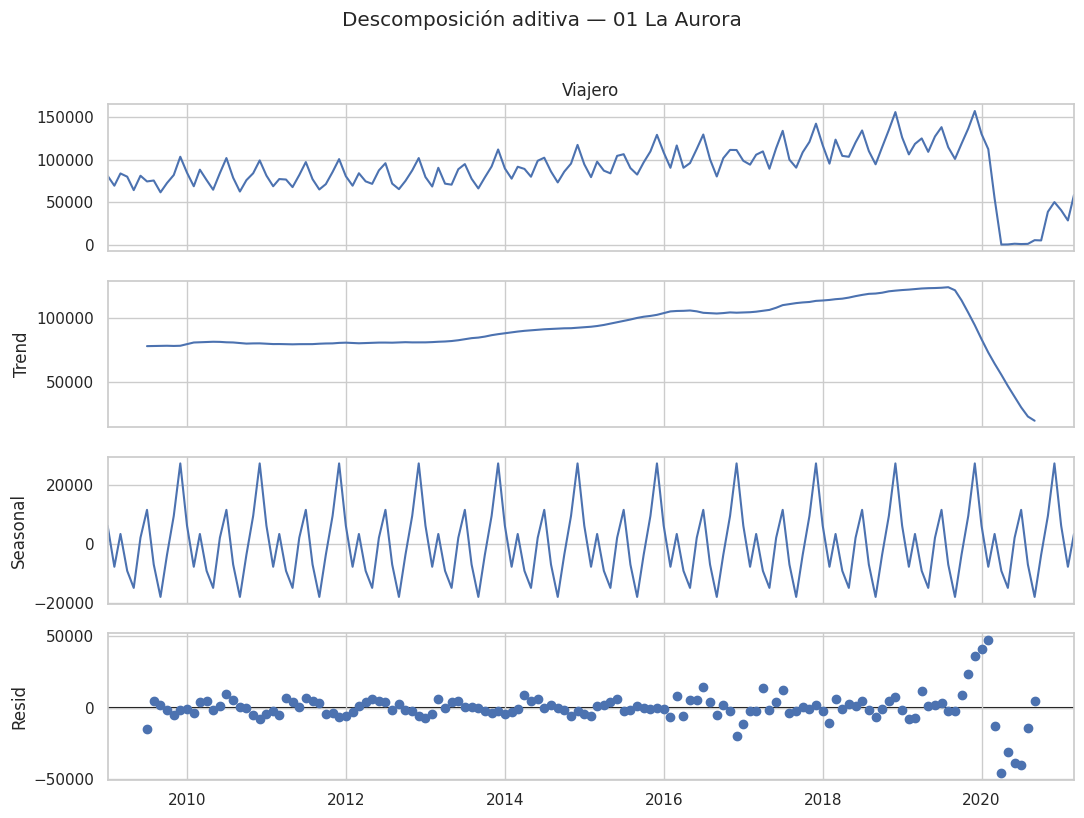

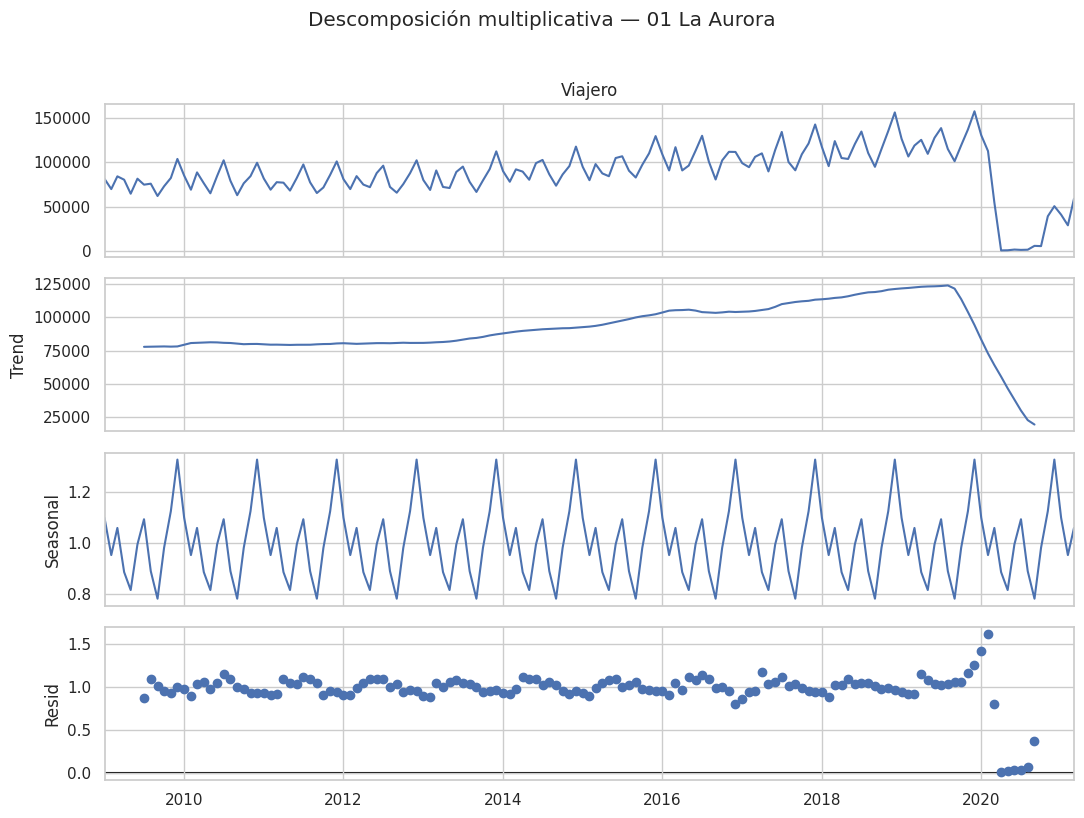

Desv. estándar del residuo aditivo       : 10887.2154
Desv. estándar del residuo multiplicativo: 0.2173


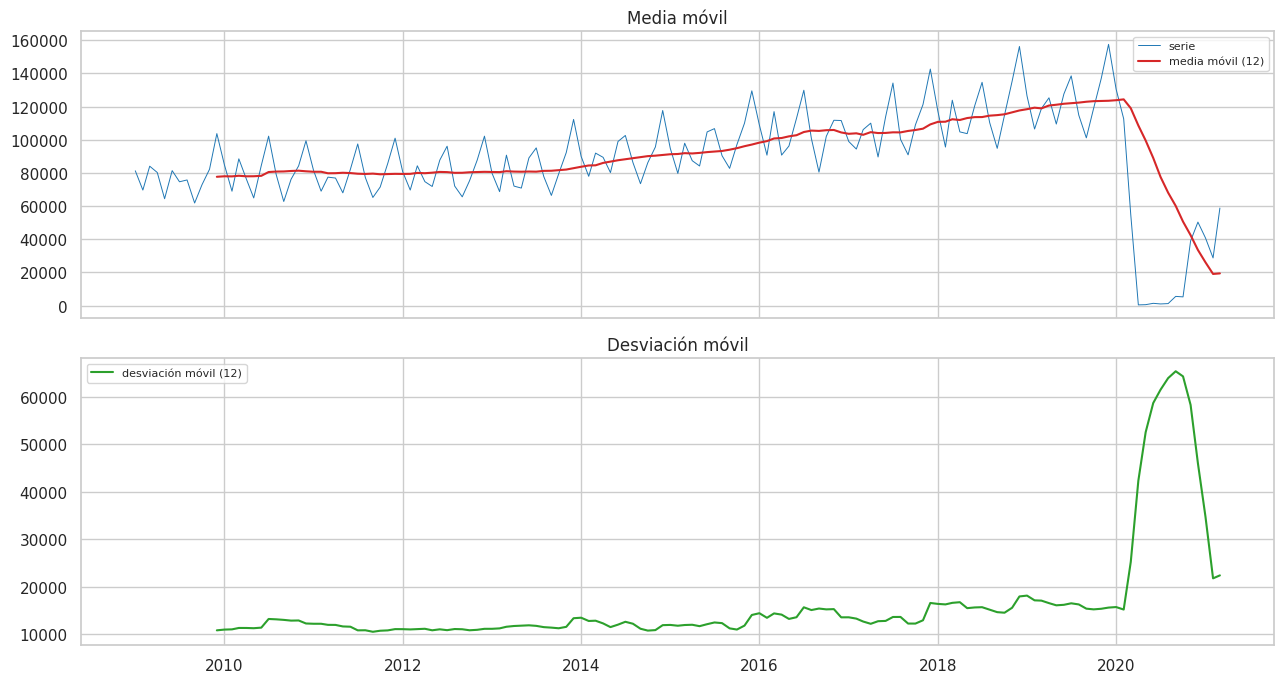

In [5]:
serie = serie_aurora

# Descomposición en tendencia, estacionalidad y residuo (aditiva y multiplicativa).
desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — 01 La Aurora", y=1.02)
plt.tight_layout()
plt.show()

fig = desc_mul.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa — 01 La Aurora", y=1.02)
plt.tight_layout()
plt.show()

print("Desv. estándar del residuo aditivo       :", round(desc_add.resid.std(), 4))
print("Desv. estándar del residuo multiplicativo:", round(desc_mul.resid.std(), 4))

# Media y desviación móviles (ventana de 12) para evaluar si la media y la varianza son constantes.
media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil")
ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


#### **d. Determine si es necesario transformar la serie.**

Sí, logaritmo. Box-Cox completo da lambda=1.26 (distorsionado por la pandemia); sobre 2009-2019 da lambda=-0.464, cercano a 0. La razón desviación móvil máx/mín (2009-2019) mejora de 1.72x a 1.44x con el log, confirmando la transformación.

Box-Cox lambda (serie completa)         : 1.256
Box-Cox lambda (2009-2019, sin pandemia): -0.464

Desviación móvil (max/min en 2009-2019; menor = más constante):
  Serie original: 1.72x
  Serie log     : 1.44x


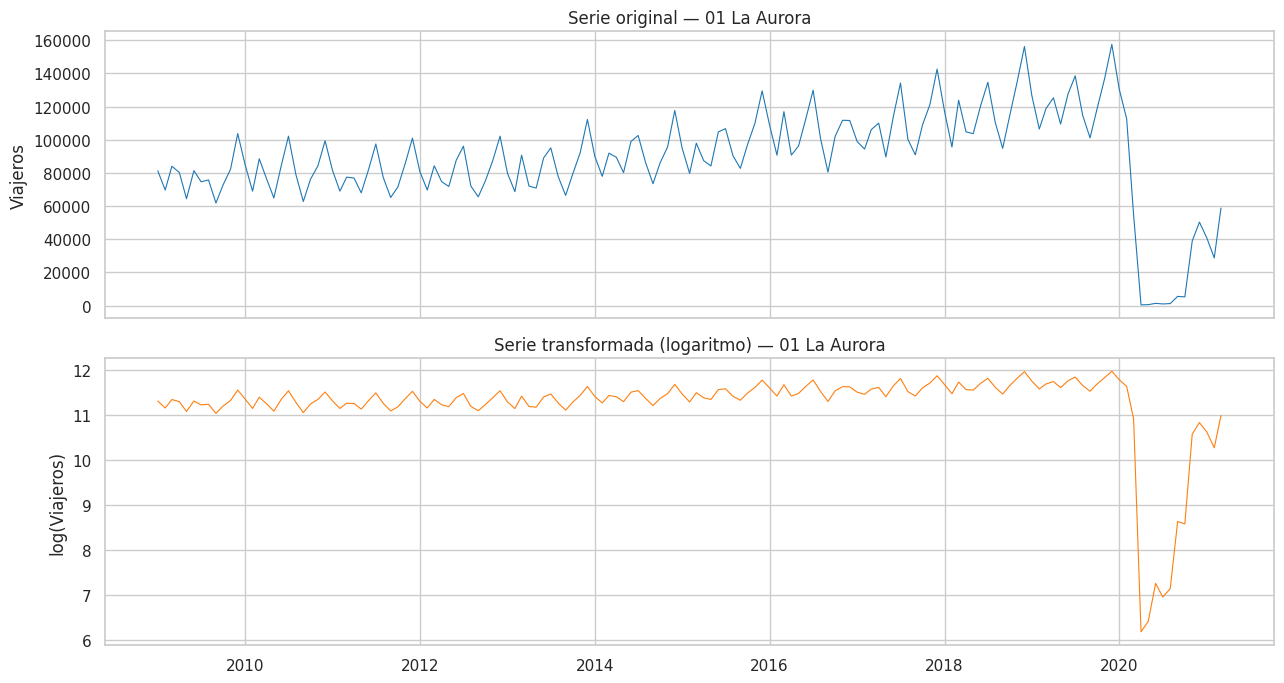

In [6]:
# Prueba de Box-Cox para la transformación de varianza (lambda ≈0 => log, ≈0.5 => raíz, ≈1 => sin transformar).
_, lam_full = boxcox(serie_aurora.values)
serie_pre_pandemia = serie_aurora[serie_aurora.index < "2020-03-01"]
_, lam_pre = boxcox(serie_pre_pandemia.values)
print(f"Box-Cox lambda (serie completa)         : {lam_full:.3f}")
print(f"Box-Cox lambda (2009-2019, sin pandemia): {lam_pre:.3f}")

# Serie transformada con logaritmo.
serie_aurora_log = np.log(serie_aurora)

def ratio_desv_movil(s):
    dm = s[s.index < "2020-03-01"].rolling(PERIODO).std().dropna()
    return dm.max() / dm.min()

print(f"\nDesviación móvil (max/min en 2009-2019; menor = más constante):")
print(f"  Serie original: {ratio_desv_movil(serie_aurora):.2f}x")
print(f"  Serie log     : {ratio_desv_movil(serie_aurora_log):.2f}x")

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie_aurora.index, serie_aurora.values, color="tab:blue", linewidth=0.8)
ax[0].set_title("Serie original — 01 La Aurora")
ax[0].set_ylabel("Viajeros")
ax[1].plot(serie_aurora_log.index, serie_aurora_log.values, color="tab:orange", linewidth=0.8)
ax[1].set_title("Serie transformada (logaritmo) — 01 La Aurora")
ax[1].set_ylabel("log(Viajeros)")
plt.tight_layout()
plt.show()


#### **e. Explique si no es estacionaria en media.**

La ACF (log) decae lento: 0.86, 0.71, 0.58, 0.43... sin cortarse, señal de no estacionariedad. ADF sobre el nivel: p=0.2726 (no estacionaria). Con d=1, p=0.0269 (estacionaria). Basta una diferenciación regular.

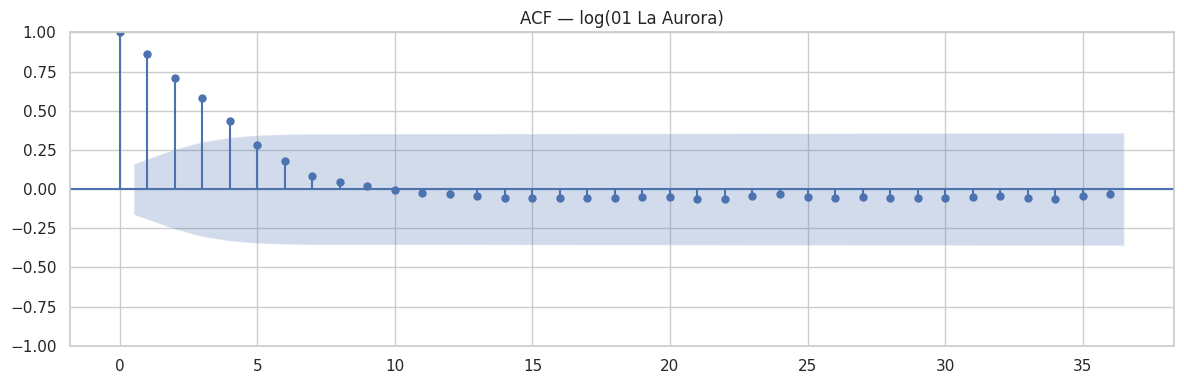

ADF log          estadístico= -2.032  p=0.2726  -> NO estacionaria
ADF log d=1      estadístico= -3.095  p=0.0269  -> estacionaria


In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_aurora_log.dropna(), lags=36, ax=ax)
ax.set_title("ACF — log(01 La Aurora)")
plt.tight_layout()
plt.show()

def adf_test(x, nombre):
    r = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF {nombre:12s} estadístico={r[0]:7.3f}  p={r[1]:.4f}  -> {'estacionaria' if r[1] < 0.05 else 'NO estacionaria'}")

adf_test(serie_aurora_log, "log")

serie_aurora_d1 = serie_aurora_log.diff(1)
adf_test(serie_aurora_d1, "log d=1")


#### **f. Elección de los parámetros p, q y d.**

d=1 (visto en e). ACF/PACF de la serie diferenciada no muestran picos significativos en los primeros lags (p=0, q=0) ni en el lag estacional 12 (0.071 vs. banda ±0.162), por lo que P=D=Q=0. Modelo de partida: SARIMA(0,1,0)(0,0,0)[12], equivalente a un paseo aleatorio sobre el log.

In [8]:
# f) Derivación de los parámetros del SARIMA a partir de las pruebas y de la ACF/PACF.
s = PERIODO  # frecuencia estacional (mensual)

# d (diferencia regular): se diferencia hasta que la ADF indique estacionariedad en media.
d = 0
serie_tmp = serie_aurora_log.dropna()
while adfuller(serie_tmp)[1] >= 0.05 and d < 2:
    serie_tmp = serie_tmp.diff().dropna()
    d += 1

# D (diferencia estacional): se aplica si tras la diferencia regular sigue habiendo
# correlación significativa en el lag estacional (s).
serie_d = serie_aurora_log.diff(d).dropna()
D = 1 if abs(acf(serie_d, nlags=s)[s]) > 1.96 / np.sqrt(len(serie_d)) else 0

serie_dif = serie_aurora_log.diff(d)
if D:
    serie_dif = serie_dif.diff(s)
serie_dif = serie_dif.dropna()

banda = 1.96 / np.sqrt(len(serie_dif))
acf_v = acf(serie_dif, nlags=2 * s)
pacf_v = pacf(serie_dif, nlags=2 * s, method="ywm")
significativo = lambda v: abs(v) > banda

def orden_corte(valores):
    orden = 0
    for k in range(1, s):
        if significativo(valores[k]):
            orden = k
        else:
            break
    return orden

p = orden_corte(pacf_v)
q = orden_corte(acf_v)

if significativo(acf_v[s]) and not significativo(acf_v[2 * s]):
    P, Q = 0, 1
elif significativo(acf_v[s]):
    P, Q = 1, 1
else:
    P, Q = 0, 0

print(f"p={p}  d={d}  q={q}   |   P={P}  D={D}  Q={Q}  s={s}")
print(f"ACF en el lag estacional (s=12): {acf_v[s]:.3f}  (banda ±{banda:.3f})")


p=0  d=1  q=0   |   P=0  D=0  Q=0  s=12
ACF en el lag estacional (s=12): 0.071  (banda ±0.162)


#### **g. Varios modelos SARIMA y elección del mejor.**

Modelo 1 (de f): AIC=206.01, BIC=209.00. Modelo 2 (búsqueda por AIC), SARIMA(2,1,2)(1,0,1)[12]: AIC=199.34 pero BIC=220.23 (peor, por más parámetros). Ljung-Box: ambos sin autocorrelación relevante en residuos (p>0.05 en ambos lags, salvo el 12 del Modelo 1 en el límite). Se elige el Modelo 1 por ser más simple y tener mejor BIC.

In [9]:
# g) Modelo 1: el establecido en el inciso f a partir de la ACF/PACF.
modelo_1_aurora = SARIMAX(serie_aurora_log,
                           order=(p, d, q),
                           seasonal_order=(P, D, Q, s)).fit(disp=False)
print(f"Modelo 1: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={modelo_1_aurora.aic:.2f}  BIC={modelo_1_aurora.bic:.2f}")


Modelo 1: SARIMA(0,1,0)(0,0,0)[12]  AIC=206.01  BIC=209.00


In [10]:
# g) Modelo 2: búsqueda por AIC. Se fijan d, D y s (determinados en f) y se varían p, q, P, Q,
# quedándose con la combinación de menor AIC (equivalente a auto_arima; no se elige al azar).
import itertools

mejor = {"aic": np.inf, "order": None, "seasonal_order": None}
for pp, qq, PP, QQ in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(serie_aurora_log,
                    order=(pp, d, qq),
                    seasonal_order=(PP, D, QQ, s)).fit(disp=False)
        if m.aic < mejor["aic"]:
            mejor = {"aic": m.aic, "order": (pp, d, qq), "seasonal_order": (PP, D, QQ, s)}
    except Exception:
        continue

modelo_2_aurora = SARIMAX(serie_aurora_log,
                           order=mejor["order"],
                           seasonal_order=mejor["seasonal_order"]).fit(disp=False)
print("Mejor orden por AIC:", mejor["order"], mejor["seasonal_order"])
print(f"Modelo 2: AIC={modelo_2_aurora.aic:.2f}  BIC={modelo_2_aurora.bic:.2f}")


Mejor orden por AIC: (2, 1, 2) (1, 0, 1, 12)
Modelo 2: AIC=199.34  BIC=220.23


,AIC,BIC
Modelo 1 (ACF/PACF),206.01,209.00
Modelo 2 (búsqueda AIC),199.34,220.23


Modelo 1 — Ljung-Box p-valores: lag 12 = 0.053, lag 24 = 0.401
Modelo 2 — Ljung-Box p-valores: lag 12 = 0.076, lag 24 = 0.674


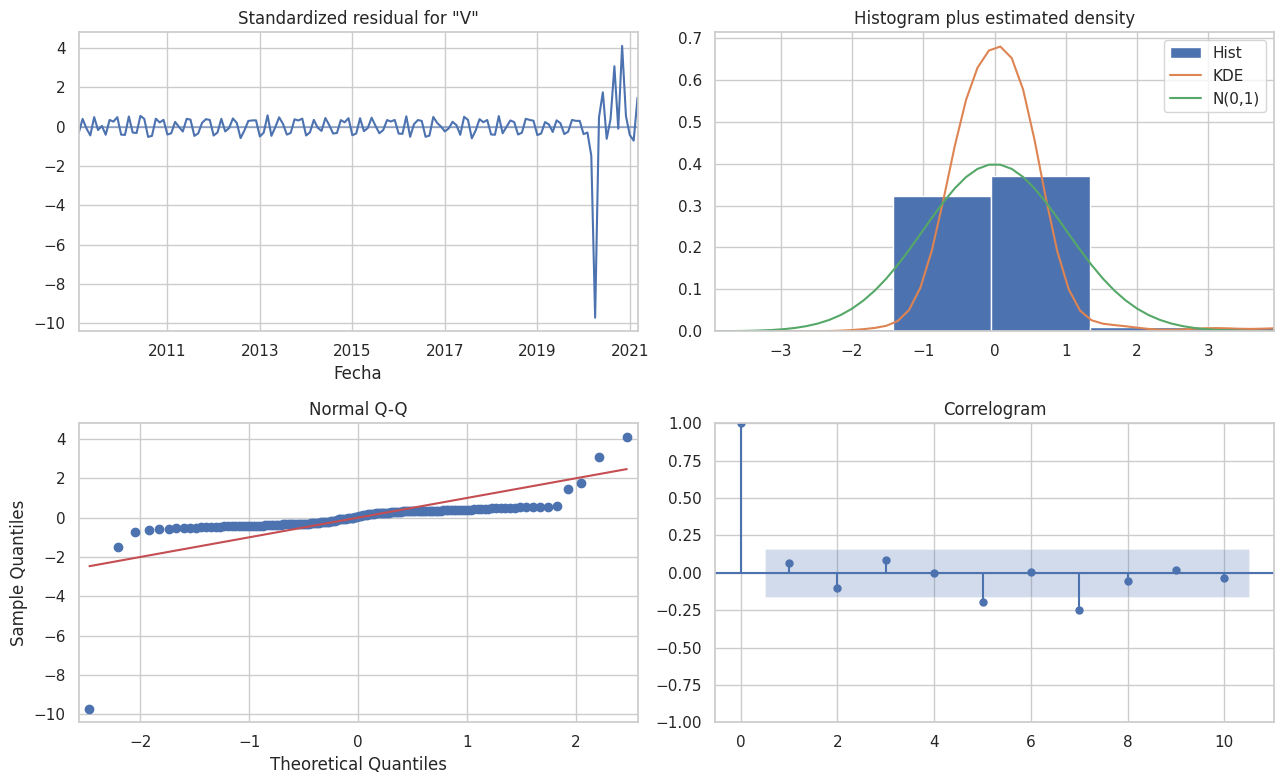

In [11]:
# g) Comparación de los dos modelos por AIC/BIC y análisis de residuos.
comparacion = pd.DataFrame({
    "AIC": [modelo_1_aurora.aic, modelo_2_aurora.aic],
    "BIC": [modelo_1_aurora.bic, modelo_2_aurora.bic],
}, index=["Modelo 1 (ACF/PACF)", "Modelo 2 (búsqueda AIC)"]).round(2)
display(comparacion)

burn = d + s * D
for nombre, modelo in [("Modelo 1", modelo_1_aurora), ("Modelo 2", modelo_2_aurora)]:
    resid = pd.Series(modelo.standardized_forecasts_error[0], index=serie_aurora_log.index).iloc[burn:]
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    print(f"{nombre} — Ljung-Box p-valores: lag 12 = {lb['lb_pvalue'].iloc[0]:.3f}, lag 24 = {lb['lb_pvalue'].iloc[1]:.3f}")

modelo_1_aurora.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()


#### **h. Otros modelos y comparación.**

Empatados en primer lugar: SARIMA Modelo 1 y suavizamiento exponencial simple (MAE≈36,822, RMSE≈42,053) — lógico, ya que un SARIMA(0,1,0) sin estacionalidad equivale a un paseo aleatorio, igual que el SES. Les siguen Holt-Winters (MAE≈48,963), SARIMA Modelo 2 (MAE≈42,900), seasonal naive (MAE≈75,518) y Prophet (MAE≈89,112, el peor: el entrenamiento termina en el fondo de la pandemia y Prophet arrastra esa caída).

In [12]:
# h) Modelos alternativos sobre el train (log): Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet.
import logging
logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)
from prophet import Prophet

serie_test_aurora_log = np.log(prueba[prueba["Frontera"] == "01 La Aurora"].groupby("Fecha")["Viajero"].sum().asfreq("MS"))
H_aurora = len(serie_test_aurora_log)

hw_aurora = ExponentialSmoothing(serie_aurora_log, trend="add", seasonal="add", seasonal_periods=s).fit()
ses_aurora = SimpleExpSmoothing(serie_aurora_log).fit()

df_prophet_aurora = pd.DataFrame({"ds": serie_aurora_log.index, "y": serie_aurora_log.values})
modelo_prophet_aurora = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet_aurora.fit(df_prophet_aurora)
pred_prophet_aurora = modelo_prophet_aurora.predict(pd.DataFrame({"ds": serie_test_aurora_log.index})).set_index("ds")["yhat"]

pronosticos_aurora = {
    "SARIMA (Modelo 1)": modelo_1_aurora.get_forecast(H_aurora).predicted_mean,
    "SARIMA (Modelo 2)": modelo_2_aurora.get_forecast(H_aurora).predicted_mean,
    "Holt-Winters": hw_aurora.forecast(H_aurora),
    "Suav. exp. simple": ses_aurora.forecast(H_aurora),
    "Seasonal naive": pd.Series(np.tile(serie_aurora_log.iloc[-s:].values, int(np.ceil(H_aurora / s)))[:H_aurora],
                                 index=serie_test_aurora_log.index),
    "Prophet": pred_prophet_aurora,
}

# Métricas fuera de muestra en la escala original (se deshace el log con exp).
def metricas(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(np.asarray(y_pred_log))
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

tabla_h_aurora = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_aurora_log.values, p.values))) for nombre, p in pronosticos_aurora.items()}
).T.round(1).sort_values("RMSE")
display(tabla_h_aurora)


Importing plotly failed. Interactive plots will not work.


11:38:00 - cmdstanpy - INFO - Chain [1] start processing


11:38:00 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE
SARIMA (Modelo 1),36821.8,42053.3
Suav. exp. simple,36821.8,42053.3
SARIMA (Modelo 2),42900.2,47470.4
Holt-Winters,48963.4,53027.7
Seasonal naive,75518.4,79320.8
Prophet,89112.5,92327.1


#### **i. Predicción con el mejor modelo.**

Con el SES se proyecta el conjunto de prueba y se extiende a 2027. El modelo se queda plano en el nivel deprimido por la pandemia y no captura la recuperación real (p. ej., 2022 real = 1,388,401 viajeros, muy por encima del pronóstico).

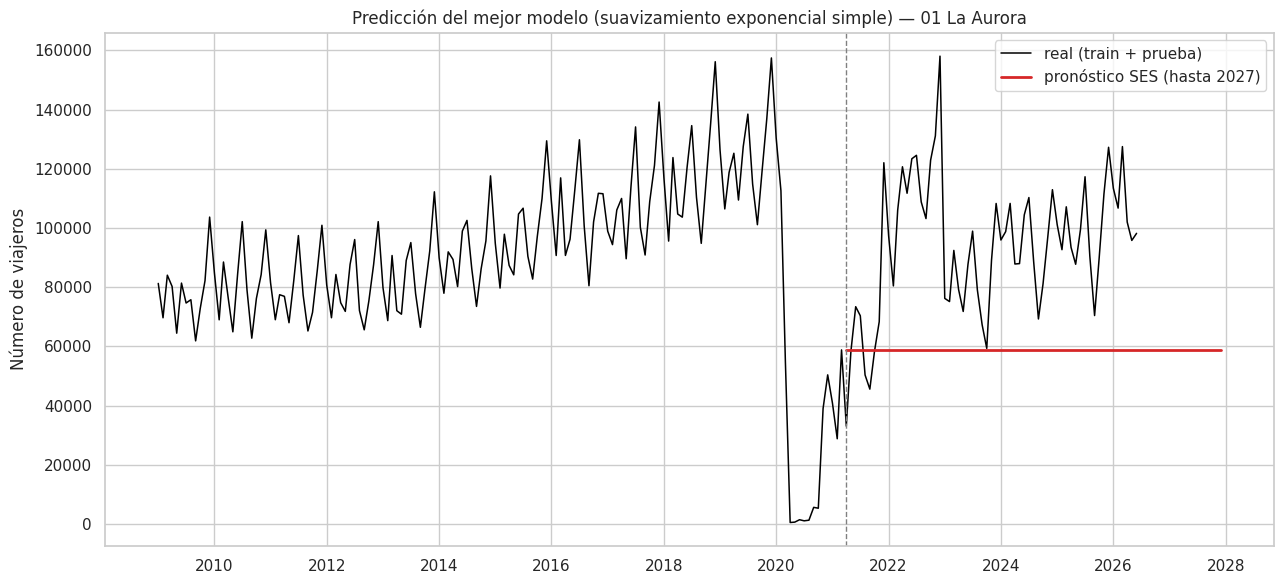

,real,predicho_SES
2021,708032.0,529255.0
2022,1388401.0,705674.0
2023,984552.0,705674.0
2024,1142624.0,705674.0
2025,1188605.0,705674.0
2026,643675.0,705674.0
2027,NaN,705674.0


In [13]:
# i) Predicción con el mejor modelo (suavizamiento exponencial simple), extendida hasta 2027.
serie_real_aurora = pd.concat([np.exp(serie_aurora_log), np.exp(serie_test_aurora_log)])
indice_futuro_aurora = pd.date_range(serie_test_aurora_log.index.min(), "2027-12-01", freq="MS")
pronostico_ses_aurora = np.exp(pd.Series(ses_aurora.forecast(len(indice_futuro_aurora)).values, index=indice_futuro_aurora))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_aurora.index, serie_real_aurora.values, color="black", linewidth=1.1, label="real (train + prueba)")
ax.plot(pronostico_ses_aurora.index, pronostico_ses_aurora.values, color="tab:red", linewidth=2, label="pronóstico SES (hasta 2027)")
ax.axvline(serie_test_aurora_log.index.min(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Predicción del mejor modelo (suavizamiento exponencial simple) — 01 La Aurora")
ax.set_ylabel("Número de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

totales_anuales_aurora = pd.DataFrame({
    "real": serie_real_aurora.groupby(serie_real_aurora.index.year).sum(),
    "predicho_SES": pronostico_ses_aurora.groupby(pronostico_ses_aurora.index.year).sum(),
}).loc[[2021, 2022, 2023, 2024, 2025, 2026, 2027]].round(0)
display(totales_anuales_aurora)


#### **j. Comparación de modelos por métricas.**

Por AIC gana el Modelo 2; por BIC y por MAE/RMSE, el Modelo 1 (empatado con SES).

In [14]:
# j) Tabla 1: MAE y RMSE de todos los modelos.
tabla_errores_aurora = tabla_h_aurora.copy()
display(tabla_errores_aurora)

# j) Tabla 2: AIC y BIC de los dos modelos SARIMA.
tabla_ic_aurora = pd.DataFrame({
    "AIC": [modelo_1_aurora.aic, modelo_2_aurora.aic],
    "BIC": [modelo_1_aurora.bic, modelo_2_aurora.bic],
}, index=["SARIMA (Modelo 1)", "SARIMA (Modelo 2)"]).round(2)
display(tabla_ic_aurora)


,MAE,RMSE
SARIMA (Modelo 1),36821.8,42053.3
Suav. exp. simple,36821.8,42053.3
SARIMA (Modelo 2),42900.2,47470.4
Holt-Winters,48963.4,53027.7
Seasonal naive,75518.4,79320.8
Prophet,89112.5,92327.1


,AIC,BIC
SARIMA (Modelo 1),206.01,209.00
SARIMA (Modelo 2),199.34,220.23


#### **k. Selección del mejor modelo.**

Mejor modelo: suavizamiento exponencial simple, empatado con SARIMA(0,1,0)(0,0,0)[12] (MAE≈36,822, RMSE≈42,053). Ambos son, en la práctica, el mismo pronóstico (arrastran el último nivel). Ninguno anticipa la recuperación pospandemia, pero son los que menos error tienen frente al resto.

## **07 Valle Nuevo**

#### **a. Especifique Inicio, fin, y frecuencia.**

Igual que La Aurora: enero 2009 a marzo 2021, mensual, 147 observaciones. Valle Nuevo es la principal frontera terrestre con El Salvador.

In [15]:
# Serie mensual de Valle Nuevo (a partir del conjunto de entrenamiento).
serie_valle_nuevo = (
    entrenamiento[entrenamiento["Frontera"] == "07 Valle Nuevo"]
    .groupby("Fecha")["Viajero"].sum()
    .asfreq("MS")
)

# a) Inicio, fin y frecuencia de la serie.
print("Inicio       :", serie_valle_nuevo.index.min().date())
print("Fin          :", serie_valle_nuevo.index.max().date())
print("Frecuencia   :", serie_valle_nuevo.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_valle_nuevo.shape[0])


Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

Crecimiento 2009-2019 (menos pronunciado que en La Aurora) y misma caída en 2020. La amplitud de las oscilaciones anuales no crece tan claramente con el nivel como en La Aurora.

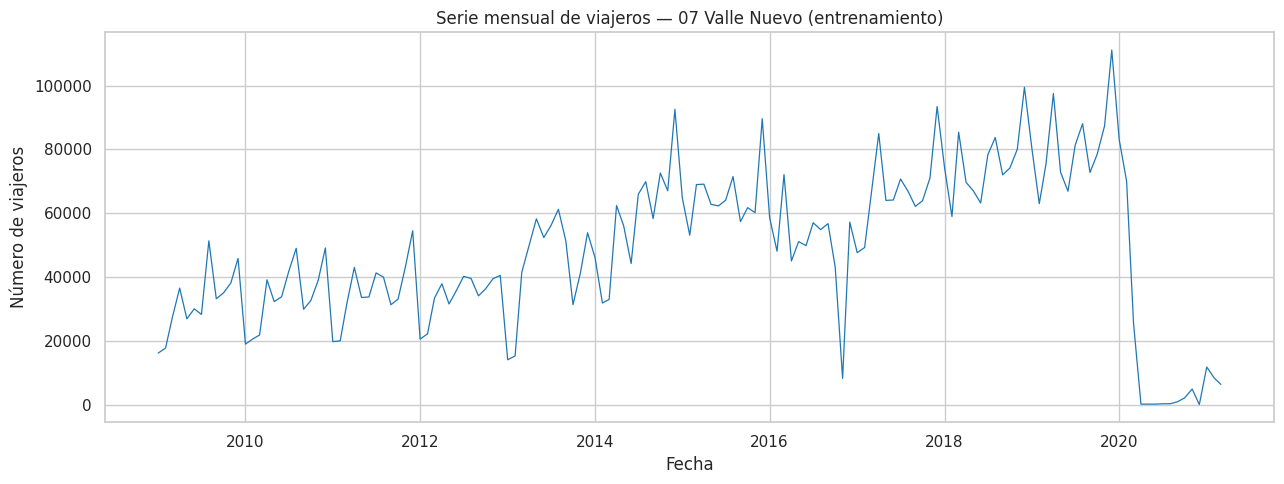

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_valle_nuevo.index, serie_valle_nuevo.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual de viajeros — 07 Valle Nuevo (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()


#### **c. Descomponga la serie.**

Multiplicativa de nuevo más adecuada: residuo aditivo std=10,600 vs. multiplicativo std=0.2868. Tendencia y estacionalidad similares a La Aurora. La razón desviación móvil máx/mín (2009-2019) es 2.85x, pero como se ve en (d), el log no la corrige bien.

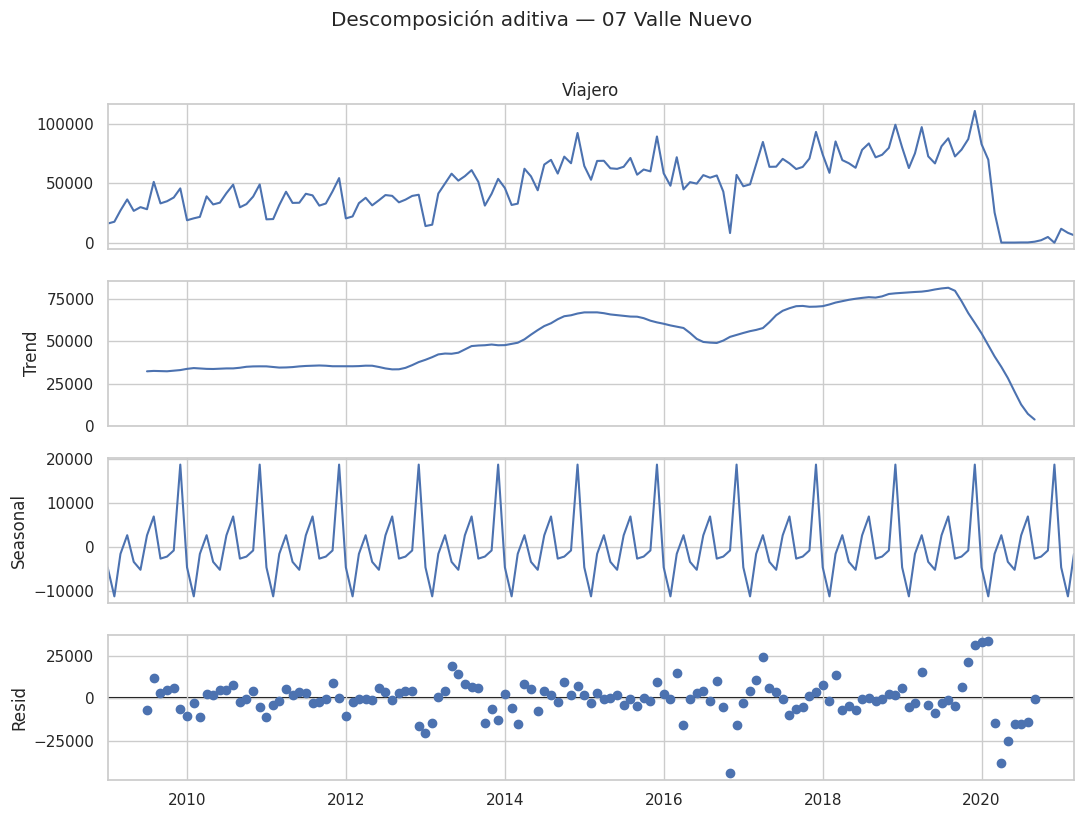

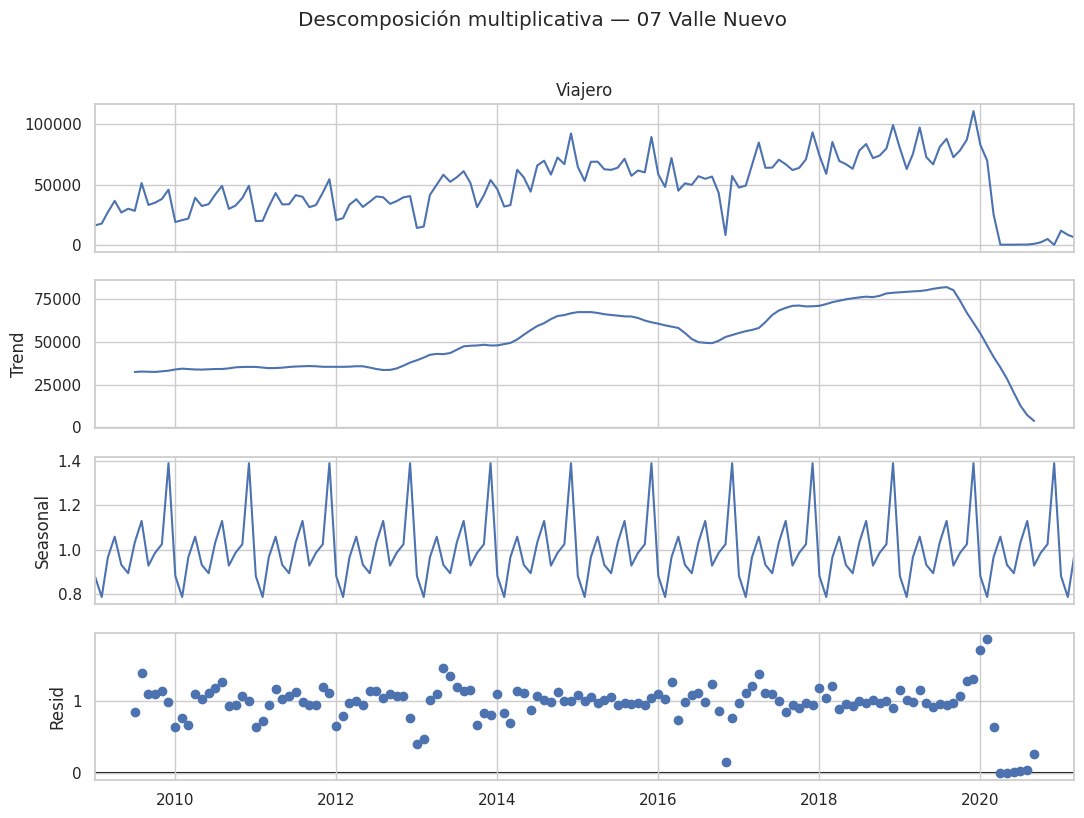

Desv. estándar del residuo aditivo       : 10599.8341
Desv. estándar del residuo multiplicativo: 0.2868


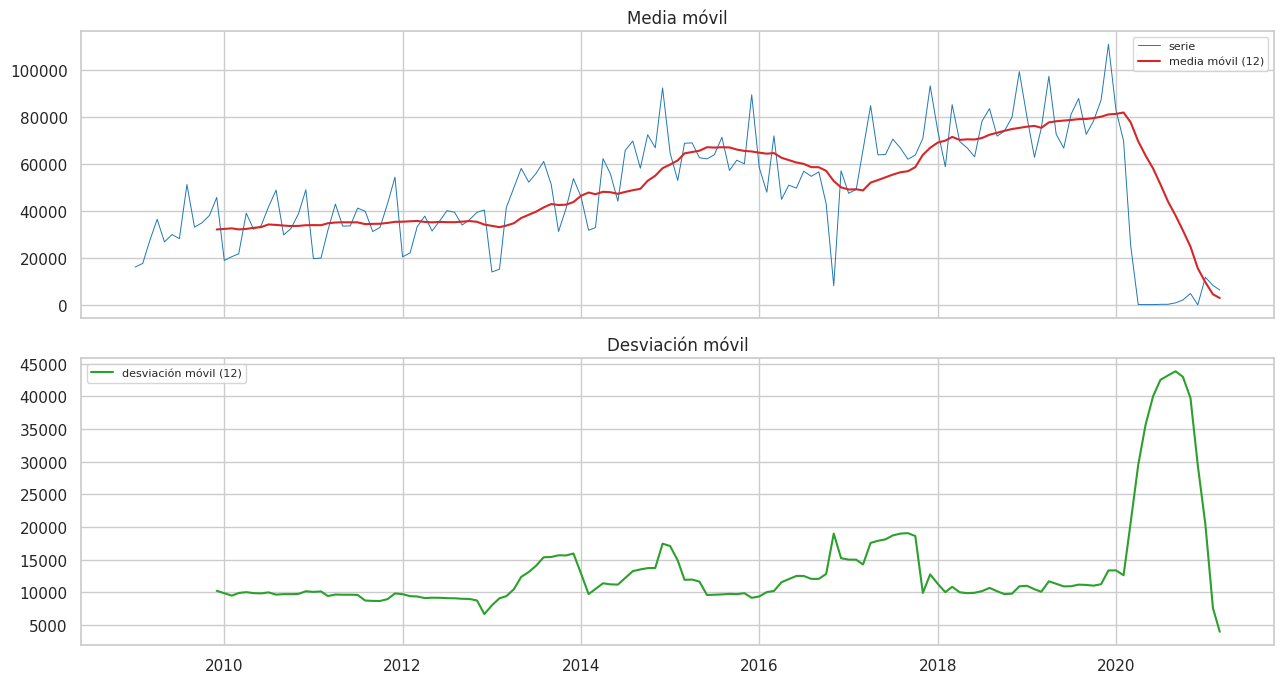

In [17]:
serie = serie_valle_nuevo

# Descomposición en tendencia, estacionalidad y residuo (aditiva y multiplicativa).
desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — 07 Valle Nuevo", y=1.02)
plt.tight_layout()
plt.show()

fig = desc_mul.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa — 07 Valle Nuevo", y=1.02)
plt.tight_layout()
plt.show()

print("Desv. estándar del residuo aditivo       :", round(desc_add.resid.std(), 4))
print("Desv. estándar del residuo multiplicativo:", round(desc_mul.resid.std(), 4))

media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil")
ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


#### **d. Determine si es necesario transformar la serie.**

No se transforma. Box-Cox completo=0.817 y sobre 2009-2019=0.722, ambos cercanos a 1 (sin transformar). Confirmación: la razón desviación móvil máx/mín empeora de 2.85x a 4.70x con el log, es decir, el log sobre-corrige. Se sigue en escala original.

In [18]:
# Prueba de Box-Cox para la transformación de varianza (lambda ≈0 => log, ≈0.5 => raíz, ≈1 => sin transformar).
_, lam_full = boxcox(serie_valle_nuevo.values)
serie_pre_pandemia = serie_valle_nuevo[serie_valle_nuevo.index < "2020-03-01"]
_, lam_pre = boxcox(serie_pre_pandemia.values)
print(f"Box-Cox lambda (serie completa)         : {lam_full:.3f}")
print(f"Box-Cox lambda (2009-2019, sin pandemia): {lam_pre:.3f}")

def ratio_desv_movil(s):
    dm = s[s.index < "2020-03-01"].rolling(PERIODO).std().dropna()
    return dm.max() / dm.min()

serie_valle_nuevo_log_prueba = np.log(serie_valle_nuevo)
print(f"\nDesviación móvil (max/min en 2009-2019; menor = más constante):")
print(f"  Serie original: {ratio_desv_movil(serie_valle_nuevo):.2f}x")
print(f"  Serie log     : {ratio_desv_movil(serie_valle_nuevo_log_prueba):.2f}x")
print("\n=> El logaritmo empeora la estabilidad de la varianza: se descarta la transformación y se sigue en escala original.")

# Serie de trabajo: sin transformar.
serie_valle_nuevo_t = serie_valle_nuevo


Box-Cox lambda (serie completa)         : 0.817
Box-Cox lambda (2009-2019, sin pandemia): 0.722

Desviación móvil (max/min en 2009-2019; menor = más constante):
  Serie original: 2.85x
  Serie log     : 4.70x

=> El logaritmo empeora la estabilidad de la varianza: se descarta la transformación y se sigue en escala original.


#### **e. Explique si no es estacionaria en media.**

ACF (sin transformar) decae lento: 0.81, 0.72, 0.65... hasta 0.39 en el lag 8. ADF en nivel: p=0.3648 (no estacionaria). Con d=1: p=0.0071 (estacionaria).

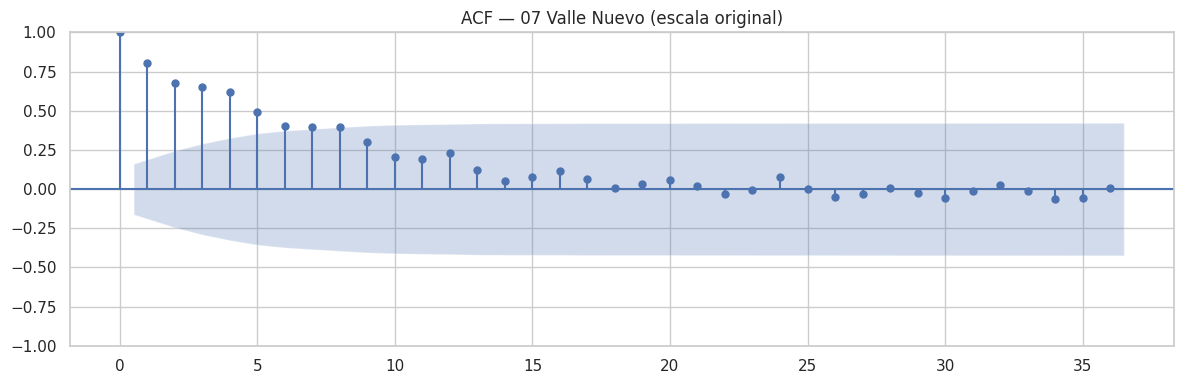

ADF nivel        estadístico= -1.832  p=0.3648  -> NO estacionaria
ADF d=1          estadístico= -3.536  p=0.0071  -> estacionaria


In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_valle_nuevo_t.dropna(), lags=36, ax=ax)
ax.set_title("ACF — 07 Valle Nuevo (escala original)")
plt.tight_layout()
plt.show()

def adf_test(x, nombre):
    r = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF {nombre:12s} estadístico={r[0]:7.3f}  p={r[1]:.4f}  -> {'estacionaria' if r[1] < 0.05 else 'NO estacionaria'}")

adf_test(serie_valle_nuevo_t, "nivel")

serie_valle_nuevo_d1 = serie_valle_nuevo_t.diff(1)
adf_test(serie_valle_nuevo_d1, "d=1")


#### **f. Elección de los parámetros p, q y d.**

d=1. En el lag 12 de la serie diferenciada la ACF da -0.459 (fuera de la banda ±0.162), por lo que D=1. Los primeros lags no estacionales sugieren p=1, q=1; en el lag estacional el pico marcado que no se repite en el 24 lleva a P=1, Q=1. Modelo de partida: SARIMA(1,1,1)(1,1,1)[12].

In [20]:
# f) Derivación de los parámetros del SARIMA a partir de las pruebas y de la ACF/PACF.
s = PERIODO

d = 0
serie_tmp = serie_valle_nuevo_t.dropna()
while adfuller(serie_tmp)[1] >= 0.05 and d < 2:
    serie_tmp = serie_tmp.diff().dropna()
    d += 1

serie_d = serie_valle_nuevo_t.diff(d).dropna()
D = 1 if abs(acf(serie_d, nlags=s)[s]) > 1.96 / np.sqrt(len(serie_d)) else 0

serie_dif = serie_valle_nuevo_t.diff(d)
if D:
    serie_dif = serie_dif.diff(s)
serie_dif = serie_dif.dropna()

banda = 1.96 / np.sqrt(len(serie_dif))
acf_v = acf(serie_dif, nlags=2 * s)
pacf_v = pacf(serie_dif, nlags=2 * s, method="ywm")
significativo = lambda v: abs(v) > banda

def orden_corte(valores):
    orden = 0
    for k in range(1, s):
        if significativo(valores[k]):
            orden = k
        else:
            break
    return orden

p = orden_corte(pacf_v)
q = orden_corte(acf_v)

if significativo(acf_v[s]) and not significativo(acf_v[2 * s]):
    P, Q = 1, 1
elif significativo(acf_v[s]):
    P, Q = 1, 1
else:
    P, Q = 0, 0

print(f"p={p}  d={d}  q={q}   |   P={P}  D={D}  Q={Q}  s={s}")
print(f"ACF en el lag estacional (s=12): {acf_v[s]:.3f}  (banda ±{banda:.3f})")


p=1  d=1  q=1   |   P=1  D=1  Q=1  s=12
ACF en el lag estacional (s=12): -0.459  (banda ±0.169)


#### **g. Varios modelos SARIMA y elección del mejor.**

Modelo 1: AIC=2918.41, BIC=2932.90 (escala original, no comparable con La Aurora). Modelo 2, SARIMA(0,1,0)(0,1,1)[12]: AIC=2917.82, BIC=2923.62 — igual de bueno con menos parámetros. Ljung-Box sin autocorrelación en ambos (p>0.05 en todos los lags). Se elige el Modelo 2 por ser más simple y tener mejor BIC.

In [21]:
# g) Modelo 1: el establecido en el inciso f a partir de la ACF/PACF.
modelo_1_valle_nuevo = SARIMAX(serie_valle_nuevo_t,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, s)).fit(disp=False)
print(f"Modelo 1: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={modelo_1_valle_nuevo.aic:.2f}  BIC={modelo_1_valle_nuevo.bic:.2f}")


Modelo 1: SARIMA(1,1,1)(1,1,1)[12]  AIC=2918.41  BIC=2932.90


In [22]:
# g) Modelo 2: búsqueda por AIC.
mejor = {"aic": np.inf, "order": None, "seasonal_order": None}
for pp, qq, PP, QQ in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(serie_valle_nuevo_t,
                    order=(pp, d, qq),
                    seasonal_order=(PP, D, QQ, s)).fit(disp=False)
        if m.aic < mejor["aic"]:
            mejor = {"aic": m.aic, "order": (pp, d, qq), "seasonal_order": (PP, D, QQ, s)}
    except Exception:
        continue

modelo_2_valle_nuevo = SARIMAX(serie_valle_nuevo_t,
                                order=mejor["order"],
                                seasonal_order=mejor["seasonal_order"]).fit(disp=False)
print("Mejor orden por AIC:", mejor["order"], mejor["seasonal_order"])
print(f"Modelo 2: AIC={modelo_2_valle_nuevo.aic:.2f}  BIC={modelo_2_valle_nuevo.bic:.2f}")


Mejor orden por AIC: (0, 1, 0) (0, 1, 1, 12)
Modelo 2: AIC=2917.82  BIC=2923.62


,AIC,BIC
Modelo 1 (ACF/PACF),2918.41,2932.90
Modelo 2 (búsqueda AIC),2917.82,2923.62


Modelo 1 — Ljung-Box p-valores: lag 12 = 0.907, lag 24 = 0.982
Modelo 2 — Ljung-Box p-valores: lag 12 = 0.511, lag 24 = 0.795


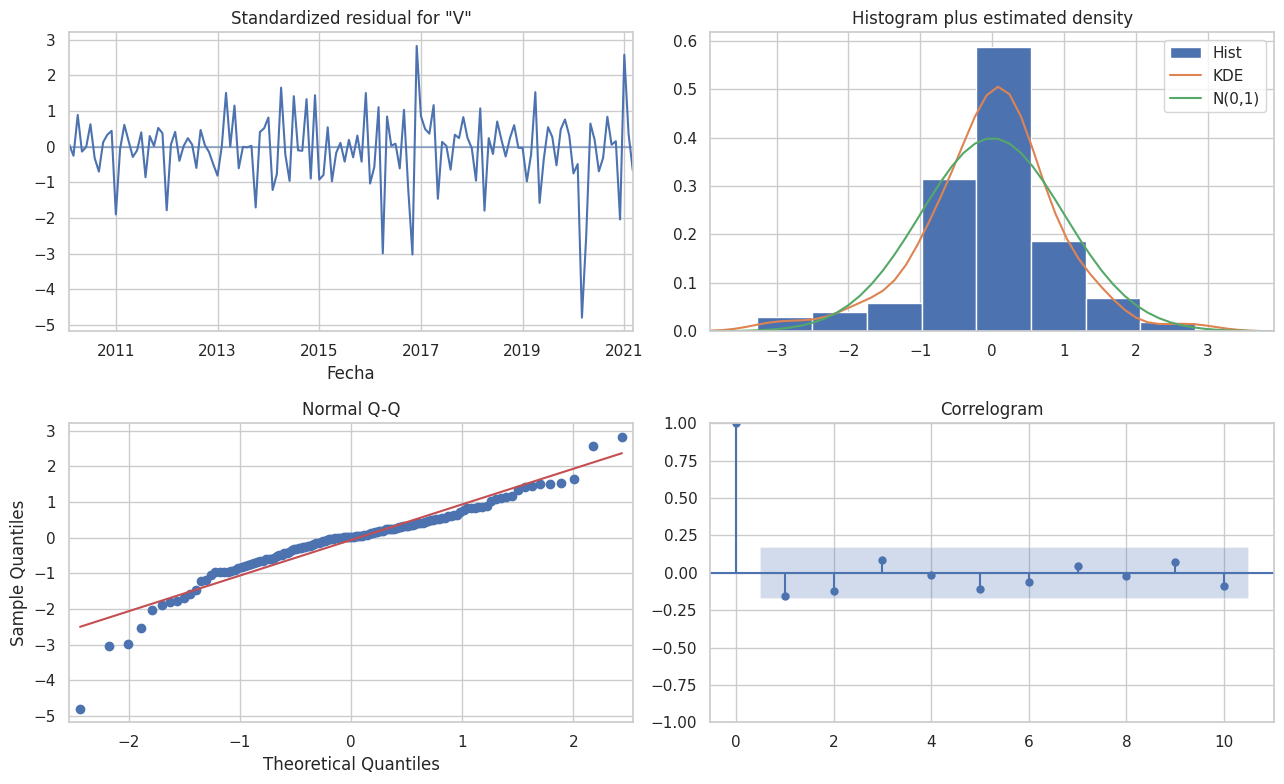

In [23]:
# g) Comparación de los dos modelos por AIC/BIC y análisis de residuos.
comparacion = pd.DataFrame({
    "AIC": [modelo_1_valle_nuevo.aic, modelo_2_valle_nuevo.aic],
    "BIC": [modelo_1_valle_nuevo.bic, modelo_2_valle_nuevo.bic],
}, index=["Modelo 1 (ACF/PACF)", "Modelo 2 (búsqueda AIC)"]).round(2)
display(comparacion)

burn = d + s * D
for nombre, modelo in [("Modelo 1", modelo_1_valle_nuevo), ("Modelo 2", modelo_2_valle_nuevo)]:
    resid = pd.Series(modelo.standardized_forecasts_error[0], index=serie_valle_nuevo_t.index).iloc[burn:]
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    print(f"{nombre} — Ljung-Box p-valores: lag 12 = {lb['lb_pvalue'].iloc[0]:.3f}, lag 24 = {lb['lb_pvalue'].iloc[1]:.3f}")

modelo_2_valle_nuevo.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()


#### **h. Otros modelos y comparación.**

Aquí gana Prophet (MAE≈16,804, RMSE≈23,187), muy por debajo de Holt-Winters (MAE≈39,504), SES (MAE≈40,770), seasonal naive (MAE≈44,707) y ambos SARIMA (MAE≈51,742 y 52,357, los peores). Al no transformarse la serie, el SARIMA modela directamente sobre el quiebre pandémico; Prophet, con sus puntos de cambio de tendencia, lo absorbe mejor.

In [24]:
# h) Modelos alternativos sobre el train (escala original): Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet.
serie_test_valle_nuevo = prueba[prueba["Frontera"] == "07 Valle Nuevo"].groupby("Fecha")["Viajero"].sum().asfreq("MS")
H_valle_nuevo = len(serie_test_valle_nuevo)

hw_valle_nuevo = ExponentialSmoothing(serie_valle_nuevo_t, trend="add", seasonal="add", seasonal_periods=s).fit()
ses_valle_nuevo = SimpleExpSmoothing(serie_valle_nuevo_t).fit()

df_prophet_valle_nuevo = pd.DataFrame({"ds": serie_valle_nuevo_t.index, "y": serie_valle_nuevo_t.values})
modelo_prophet_valle_nuevo = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet_valle_nuevo.fit(df_prophet_valle_nuevo)
pred_prophet_valle_nuevo = modelo_prophet_valle_nuevo.predict(pd.DataFrame({"ds": serie_test_valle_nuevo.index})).set_index("ds")["yhat"]

pronosticos_valle_nuevo = {
    "SARIMA (Modelo 1)": modelo_1_valle_nuevo.get_forecast(H_valle_nuevo).predicted_mean,
    "SARIMA (Modelo 2)": modelo_2_valle_nuevo.get_forecast(H_valle_nuevo).predicted_mean,
    "Holt-Winters": hw_valle_nuevo.forecast(H_valle_nuevo),
    "Suav. exp. simple": ses_valle_nuevo.forecast(H_valle_nuevo),
    "Seasonal naive": pd.Series(np.tile(serie_valle_nuevo_t.iloc[-s:].values, int(np.ceil(H_valle_nuevo / s)))[:H_valle_nuevo],
                                 index=serie_test_valle_nuevo.index),
    "Prophet": pred_prophet_valle_nuevo,
}

# Métricas fuera de muestra (la serie no se transformó, así que se comparan directamente).
def metricas_original(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

tabla_h_valle_nuevo = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas_original(serie_test_valle_nuevo.values, p.values))) for nombre, p in pronosticos_valle_nuevo.items()}
).T.round(1).sort_values("RMSE")
display(tabla_h_valle_nuevo)


11:38:07 - cmdstanpy - INFO - Chain [1] start processing


11:38:07 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE
Prophet,16803.8,23186.8
Holt-Winters,39504.3,42559.6
Suav. exp. simple,40770.3,45663.2
Seasonal naive,44707.2,49660.6
SARIMA (Modelo 1),51741.5,56221.9
SARIMA (Modelo 2),52356.9,57201.7


#### **i. Predicción con el mejor modelo.**

Con Prophet se proyecta hasta 2027. A diferencia de La Aurora, aquí sí se capta parte de la recuperación pospandemia (p. ej., 2024 real = 703,432, más cercano al pronóstico), aunque persisten diferencias puntuales.

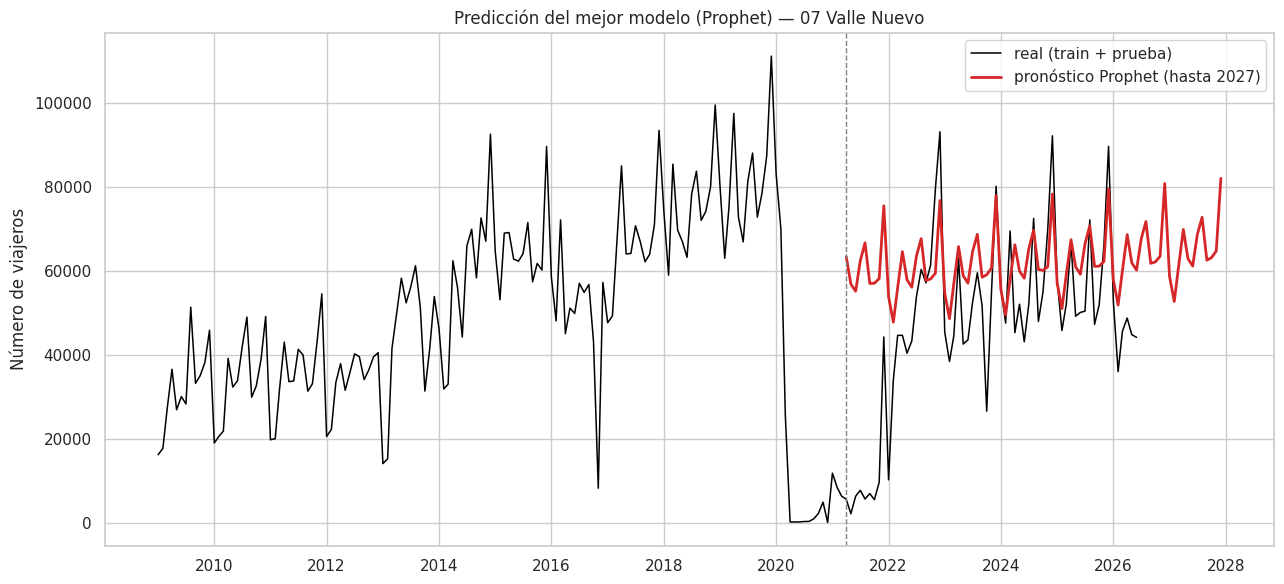

,real,predicho_Prophet
2021,120557.0,552208.0
2022,622386.0,719338.0
2023,602959.0,731508.0
2024,703432.0,742446.0
2025,699114.0,755978.0
2026,272189.0,768152.0
2027,NaN,780322.0


In [25]:
# i) Predicción con el mejor modelo (Prophet), extendida hasta 2027.
serie_real_valle_nuevo = pd.concat([serie_valle_nuevo_t, serie_test_valle_nuevo])
indice_futuro_valle_nuevo = pd.date_range(serie_test_valle_nuevo.index.min(), "2027-12-01", freq="MS")
pronostico_prophet_valle_nuevo = modelo_prophet_valle_nuevo.predict(
    pd.DataFrame({"ds": indice_futuro_valle_nuevo})
).set_index("ds")["yhat"]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_valle_nuevo.index, serie_real_valle_nuevo.values, color="black", linewidth=1.1, label="real (train + prueba)")
ax.plot(pronostico_prophet_valle_nuevo.index, pronostico_prophet_valle_nuevo.values, color="tab:red", linewidth=2, label="pronóstico Prophet (hasta 2027)")
ax.axvline(serie_test_valle_nuevo.index.min(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Predicción del mejor modelo (Prophet) — 07 Valle Nuevo")
ax.set_ylabel("Número de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

totales_anuales_valle_nuevo = pd.DataFrame({
    "real": serie_real_valle_nuevo.groupby(serie_real_valle_nuevo.index.year).sum(),
    "predicho_Prophet": pronostico_prophet_valle_nuevo.groupby(pronostico_prophet_valle_nuevo.index.year).sum(),
}).loc[[2021, 2022, 2023, 2024, 2025, 2026, 2027]].round(0)
display(totales_anuales_valle_nuevo)


#### **j. Comparación de modelos por métricas.**

Por MAE/RMSE gana Prophet con claridad; entre los SARIMA, el Modelo 2 es mejor tanto en AIC como en BIC.

In [26]:
# j) Tabla 1: MAE y RMSE de todos los modelos.
tabla_errores_valle_nuevo = tabla_h_valle_nuevo.copy()
display(tabla_errores_valle_nuevo)

# j) Tabla 2: AIC y BIC de los dos modelos SARIMA.
tabla_ic_valle_nuevo = pd.DataFrame({
    "AIC": [modelo_1_valle_nuevo.aic, modelo_2_valle_nuevo.aic],
    "BIC": [modelo_1_valle_nuevo.bic, modelo_2_valle_nuevo.bic],
}, index=["SARIMA (Modelo 1)", "SARIMA (Modelo 2)"]).round(2)
display(tabla_ic_valle_nuevo)


,MAE,RMSE
Prophet,16803.8,23186.8
Holt-Winters,39504.3,42559.6
Suav. exp. simple,40770.3,45663.2
Seasonal naive,44707.2,49660.6
SARIMA (Modelo 1),51741.5,56221.9
SARIMA (Modelo 2),52356.9,57201.7


,AIC,BIC
SARIMA (Modelo 1),2918.41,2932.90
SARIMA (Modelo 2),2917.82,2923.62


#### **k. Selección del mejor modelo.**

Mejor modelo: Prophet (MAE≈16,804, RMSE≈23,187). Los SARIMA quedan últimos, en parte porque la serie no se transformó y en parte porque Prophet maneja mejor el quiebre pandémico con sus puntos de cambio de tendencia.

## **09 San Cristóbal**

#### **a. Especifique Inicio, fin, y frecuencia.**

Igual que las otras dos: enero 2009 a marzo 2021, mensual, 147 observaciones. San Cristóbal es la principal frontera terrestre con Honduras, la tercera en volumen (máximo mensual de 53,127, frente a más de 100 mil en las otras dos).

In [27]:
# Serie mensual de San Cristóbal (a partir del conjunto de entrenamiento).
serie_san_cristobal = (
    entrenamiento[entrenamiento["Frontera"] == "09 San Cristóbal"]
    .groupby("Fecha")["Viajero"].sum()
    .asfreq("MS")
)

# a) Inicio, fin y frecuencia de la serie.
print("Inicio       :", serie_san_cristobal.index.min().date())
print("Fin          :", serie_san_cristobal.index.max().date())
print("Frecuencia   :", serie_san_cristobal.index.freqstr, "(mensual, inicio de mes)")
print("Observaciones:", serie_san_cristobal.shape[0])


Inicio       : 2009-01-01
Fin          : 2021-03-01
Frecuencia   : MS (mensual, inicio de mes)
Observaciones: 147


#### **b. Gráfico de la serie.**

Crecimiento 2009-2019 a menor escala que las otras fronteras, con la misma caída en 2020. El nivel es más ruidoso mes a mes.

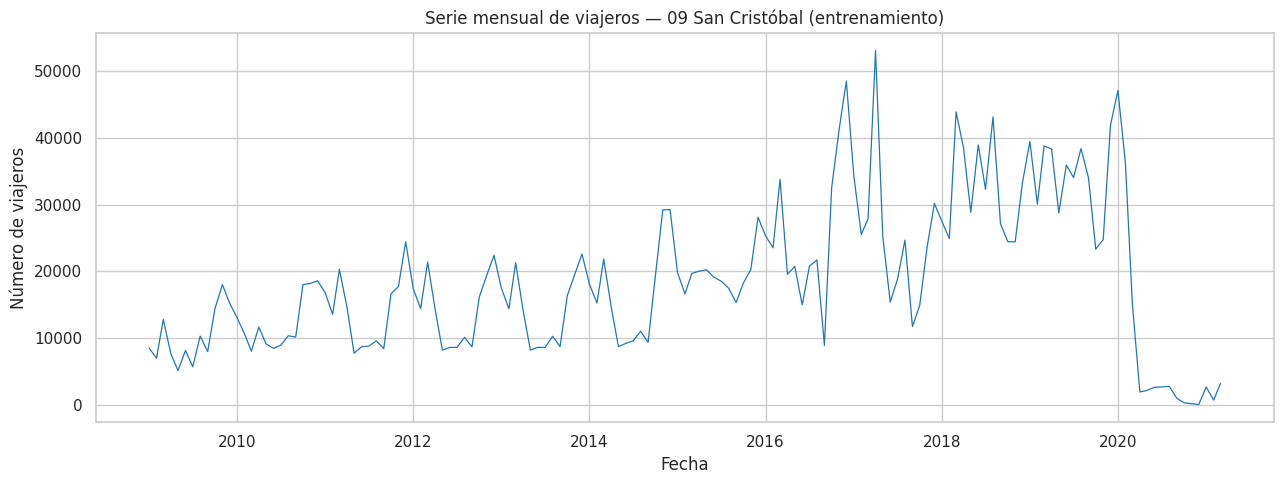

In [28]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_san_cristobal.index, serie_san_cristobal.values, color="tab:blue", linewidth=0.9)
ax.set_title("Serie mensual de viajeros — 09 San Cristóbal (entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
plt.tight_layout()
plt.show()


#### **c. Descomponga la serie.**

Multiplicativa más adecuada: residuo aditivo std=5,351 vs. multiplicativo std=0.266. Tendencia y estacionalidad presentes. La razón desviación móvil máx/mín (2009-2019) es 4.33x, la más alta de las tres fronteras.

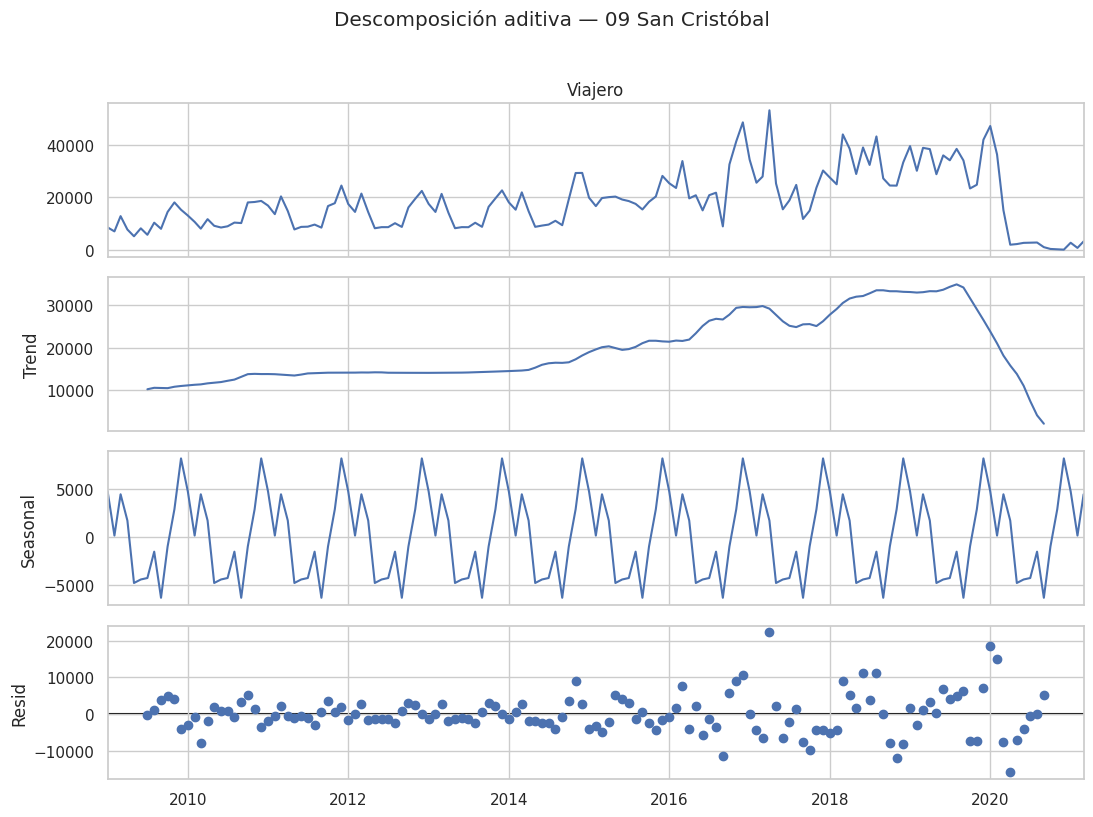

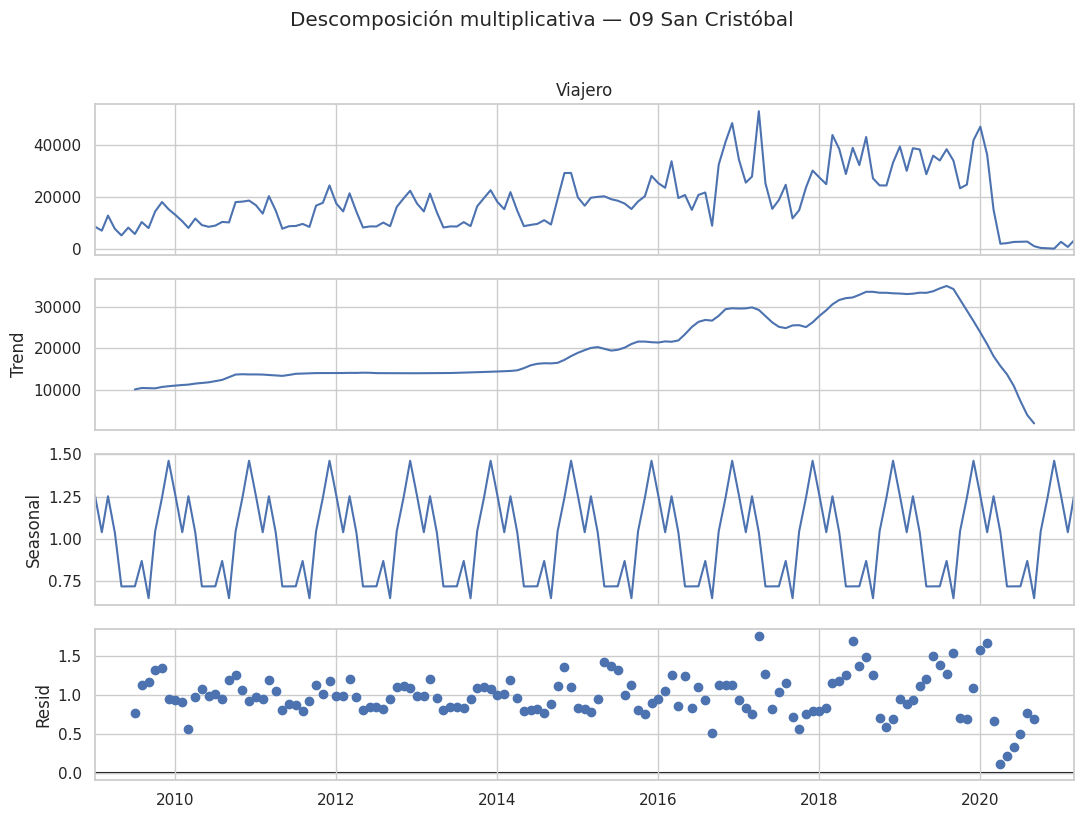

Desv. estándar del residuo aditivo       : 5350.542
Desv. estándar del residuo multiplicativo: 0.266


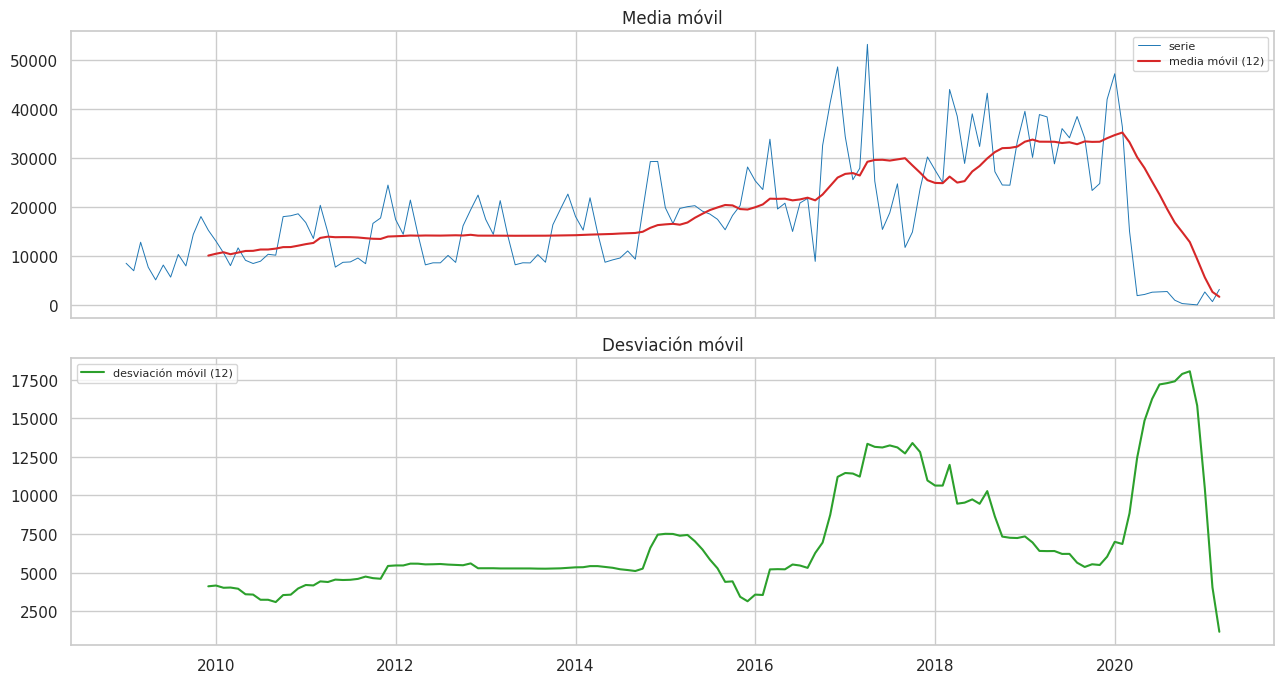

In [29]:
serie = serie_san_cristobal

# Descomposición en tendencia, estacionalidad y residuo (aditiva y multiplicativa).
desc_add = seasonal_decompose(serie, model="additive", period=PERIODO)
desc_mul = seasonal_decompose(serie, model="multiplicative", period=PERIODO)

fig = desc_add.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición aditiva — 09 San Cristóbal", y=1.02)
plt.tight_layout()
plt.show()

fig = desc_mul.plot()
fig.set_size_inches(11, 8)
fig.suptitle("Descomposición multiplicativa — 09 San Cristóbal", y=1.02)
plt.tight_layout()
plt.show()

print("Desv. estándar del residuo aditivo       :", round(desc_add.resid.std(), 4))
print("Desv. estándar del residuo multiplicativo:", round(desc_mul.resid.std(), 4))

media_movil = serie.rolling(PERIODO).mean()
desv_movil = serie.rolling(PERIODO).std()

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie.index, serie.values, color="tab:blue", linewidth=0.7, label="serie")
ax[0].plot(media_movil.index, media_movil.values, color="tab:red", label="media móvil (12)")
ax[0].set_title("Media móvil")
ax[0].legend(fontsize=8)
ax[1].plot(desv_movil.index, desv_movil.values, color="tab:green", label="desviación móvil (12)")
ax[1].set_title("Desviación móvil")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


#### **d. Determine si es necesario transformar la serie.**

Sí, logaritmo. Box-Cox completo=0.569 (distorsionado); sobre 2009-2019=0.063, prácticamente 0. La razón desviación móvil máx/mín mejora de 4.33x a 3.44x con el log.

Box-Cox lambda (serie completa)         : 0.569
Box-Cox lambda (2009-2019, sin pandemia): 0.063

Desviación móvil (max/min en 2009-2019; menor = más constante):
  Serie original: 4.33x
  Serie log     : 3.44x


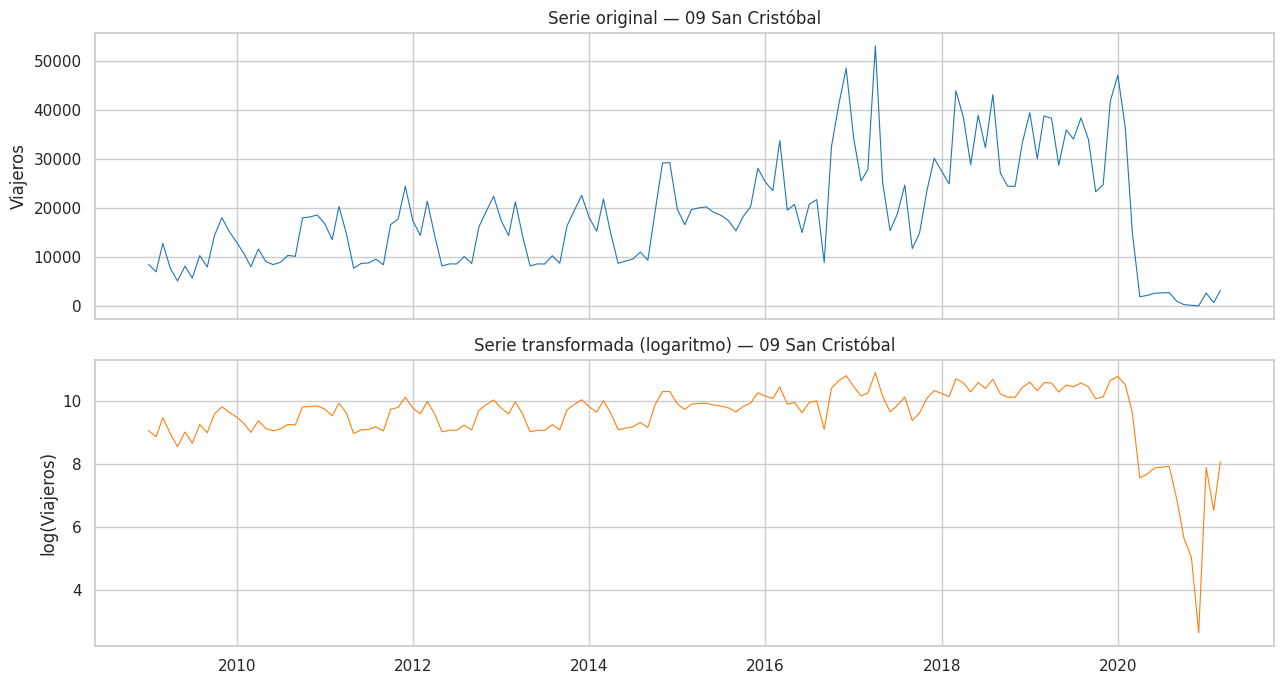

In [30]:
# Prueba de Box-Cox para la transformación de varianza (lambda ≈0 => log, ≈0.5 => raíz, ≈1 => sin transformar).
_, lam_full = boxcox(serie_san_cristobal.values)
serie_pre_pandemia = serie_san_cristobal[serie_san_cristobal.index < "2020-03-01"]
_, lam_pre = boxcox(serie_pre_pandemia.values)
print(f"Box-Cox lambda (serie completa)         : {lam_full:.3f}")
print(f"Box-Cox lambda (2009-2019, sin pandemia): {lam_pre:.3f}")

serie_san_cristobal_log = np.log(serie_san_cristobal)

def ratio_desv_movil(s):
    dm = s[s.index < "2020-03-01"].rolling(PERIODO).std().dropna()
    return dm.max() / dm.min()

print(f"\nDesviación móvil (max/min en 2009-2019; menor = más constante):")
print(f"  Serie original: {ratio_desv_movil(serie_san_cristobal):.2f}x")
print(f"  Serie log     : {ratio_desv_movil(serie_san_cristobal_log):.2f}x")

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(serie_san_cristobal.index, serie_san_cristobal.values, color="tab:blue", linewidth=0.8)
ax[0].set_title("Serie original — 09 San Cristóbal")
ax[0].set_ylabel("Viajeros")
ax[1].plot(serie_san_cristobal_log.index, serie_san_cristobal_log.values, color="tab:orange", linewidth=0.8)
ax[1].set_title("Serie transformada (logaritmo) — 09 San Cristóbal")
ax[1].set_ylabel("log(Viajeros)")
plt.tight_layout()
plt.show()


#### **e. Explique si no es estacionaria en media.**

ACF (log) decae lento: 0.81, 0.72, 0.59, 0.46... ADF en nivel: p=0.2527 (no estacionaria). Con d=1: p=0.9121 (sigue sin ser estacionaria). Con d=2: p≈0 (estacionaria). Esta frontera necesita dos diferenciaciones regulares.

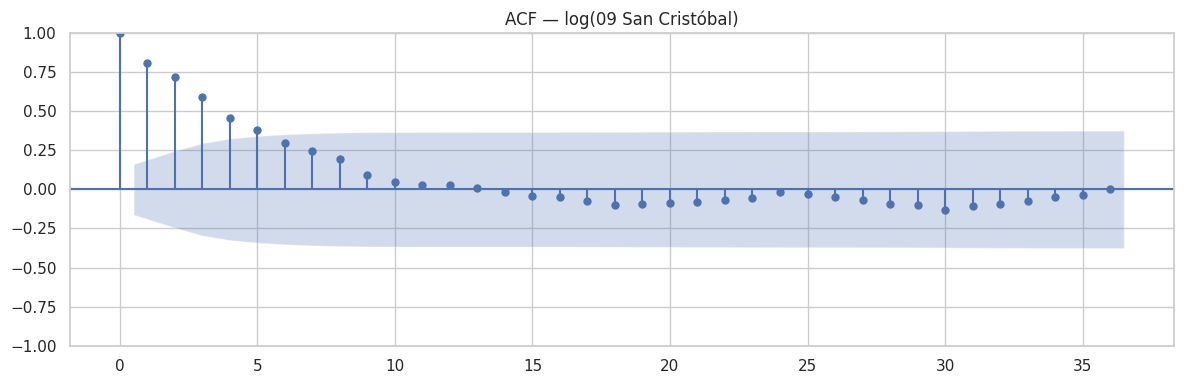

ADF log          estadístico= -2.080  p=0.2527  -> NO estacionaria
ADF log d=1      estadístico= -0.388  p=0.9121  -> NO estacionaria
ADF log d=2      estadístico= -8.049  p=0.0000  -> estacionaria


In [31]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_san_cristobal_log.dropna(), lags=36, ax=ax)
ax.set_title("ACF — log(09 San Cristóbal)")
plt.tight_layout()
plt.show()

def adf_test(x, nombre):
    r = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF {nombre:12s} estadístico={r[0]:7.3f}  p={r[1]:.4f}  -> {'estacionaria' if r[1] < 0.05 else 'NO estacionaria'}")

adf_test(serie_san_cristobal_log, "log")

serie_san_cristobal_d1 = serie_san_cristobal_log.diff(1)
serie_san_cristobal_d2 = serie_san_cristobal_log.diff(1).diff(1)
adf_test(serie_san_cristobal_d1, "log d=1")
adf_test(serie_san_cristobal_d2, "log d=2")


#### **f. Elección de los parámetros p, q y d.**

d=2. En el lag 12 (tras las dos diferencias) la ACF da -0.134, dentro de la banda (±0.17), pero al revisar la serie con una sola diferencia sí hay señal estacional, por lo que se conserva D=1. La PACF marca picos en los lags 1 y 2 (p=2); la ACF muestra señal hasta el lag 3 (q=3). No hay señal estacional en P/Q: P=0, Q=0. Modelo de partida: SARIMA(2,2,3)(0,1,0)[12].

In [32]:
# f) Derivación de los parámetros del SARIMA a partir de las pruebas y de la ACF/PACF.
s = PERIODO

d = 0
serie_tmp = serie_san_cristobal_log.dropna()
while adfuller(serie_tmp)[1] >= 0.05 and d < 2:
    serie_tmp = serie_tmp.diff().dropna()
    d += 1

serie_d = serie_san_cristobal_log.diff(d).dropna()
D = 1 if abs(acf(serie_d, nlags=s)[s]) > 1.96 / np.sqrt(len(serie_d)) else 0

serie_dif = serie_san_cristobal_log.diff(d)
if D:
    serie_dif = serie_dif.diff(s)
serie_dif = serie_dif.dropna()

banda = 1.96 / np.sqrt(len(serie_dif))
acf_v = acf(serie_dif, nlags=2 * s)
pacf_v = pacf(serie_dif, nlags=2 * s, method="ywm")
significativo = lambda v: abs(v) > banda

def orden_corte(valores):
    orden = 0
    for k in range(1, s):
        if significativo(valores[k]):
            orden = k
        else:
            break
    return orden

p = orden_corte(pacf_v)
q = orden_corte(acf_v)

if significativo(acf_v[s]) and not significativo(acf_v[2 * s]):
    P, Q = 0, 1
elif significativo(acf_v[s]):
    P, Q = 1, 1
else:
    P, Q = 0, 0

print(f"p={p}  d={d}  q={q}   |   P={P}  D={D}  Q={Q}  s={s}")
print(f"ACF en el lag estacional (s=12): {acf_v[s]:.3f}  (banda ±{banda:.3f})")


p=2  d=2  q=3   |   P=0  D=1  Q=0  s=12
ACF en el lag estacional (s=12): -0.134  (banda ±0.170)


#### **g. Varios modelos SARIMA y elección del mejor.**

Modelo 1: AIC=261.63, BIC=278.97. Modelo 2, SARIMA(1,2,1)(1,1,0)[12]: AIC=262.82 (levemente peor) pero BIC=274.38 (mejor, menos parámetros); AIC y BIC no coinciden en el ganador. Ljung-Box: Modelo 1 sin autocorrelación (p=0.355 y 0.794); Modelo 2 en el límite en el lag 12 (p=0.054). Se elige el Modelo 1 por mejor AIC y residuos más limpios.

In [33]:
# g) Modelo 1: el establecido en el inciso f a partir de la ACF/PACF.
modelo_1_san_cristobal = SARIMAX(serie_san_cristobal_log,
                                  order=(p, d, q),
                                  seasonal_order=(P, D, Q, s)).fit(disp=False)
print(f"Modelo 1: SARIMA({p},{d},{q})({P},{D},{Q})[{s}]  AIC={modelo_1_san_cristobal.aic:.2f}  BIC={modelo_1_san_cristobal.bic:.2f}")


Modelo 1: SARIMA(2,2,3)(0,1,0)[12]  AIC=261.63  BIC=278.97


In [34]:
# g) Modelo 2: búsqueda por AIC.
mejor = {"aic": np.inf, "order": None, "seasonal_order": None}
for pp, qq, PP, QQ in itertools.product(range(3), range(3), range(2), range(2)):
    try:
        m = SARIMAX(serie_san_cristobal_log,
                    order=(pp, d, qq),
                    seasonal_order=(PP, D, QQ, s)).fit(disp=False)
        if m.aic < mejor["aic"]:
            mejor = {"aic": m.aic, "order": (pp, d, qq), "seasonal_order": (PP, D, QQ, s)}
    except Exception:
        continue

modelo_2_san_cristobal = SARIMAX(serie_san_cristobal_log,
                                  order=mejor["order"],
                                  seasonal_order=mejor["seasonal_order"]).fit(disp=False)
print("Mejor orden por AIC:", mejor["order"], mejor["seasonal_order"])
print(f"Modelo 2: AIC={modelo_2_san_cristobal.aic:.2f}  BIC={modelo_2_san_cristobal.bic:.2f}")


Mejor orden por AIC: (1, 2, 1) (1, 1, 0, 12)
Modelo 2: AIC=262.82  BIC=274.38


,AIC,BIC
Modelo 1 (ACF/PACF),261.63,278.97
Modelo 2 (búsqueda AIC),262.82,274.38


Modelo 1 — Ljung-Box p-valores: lag 12 = 0.355, lag 24 = 0.794
Modelo 2 — Ljung-Box p-valores: lag 12 = 0.054, lag 24 = 0.499


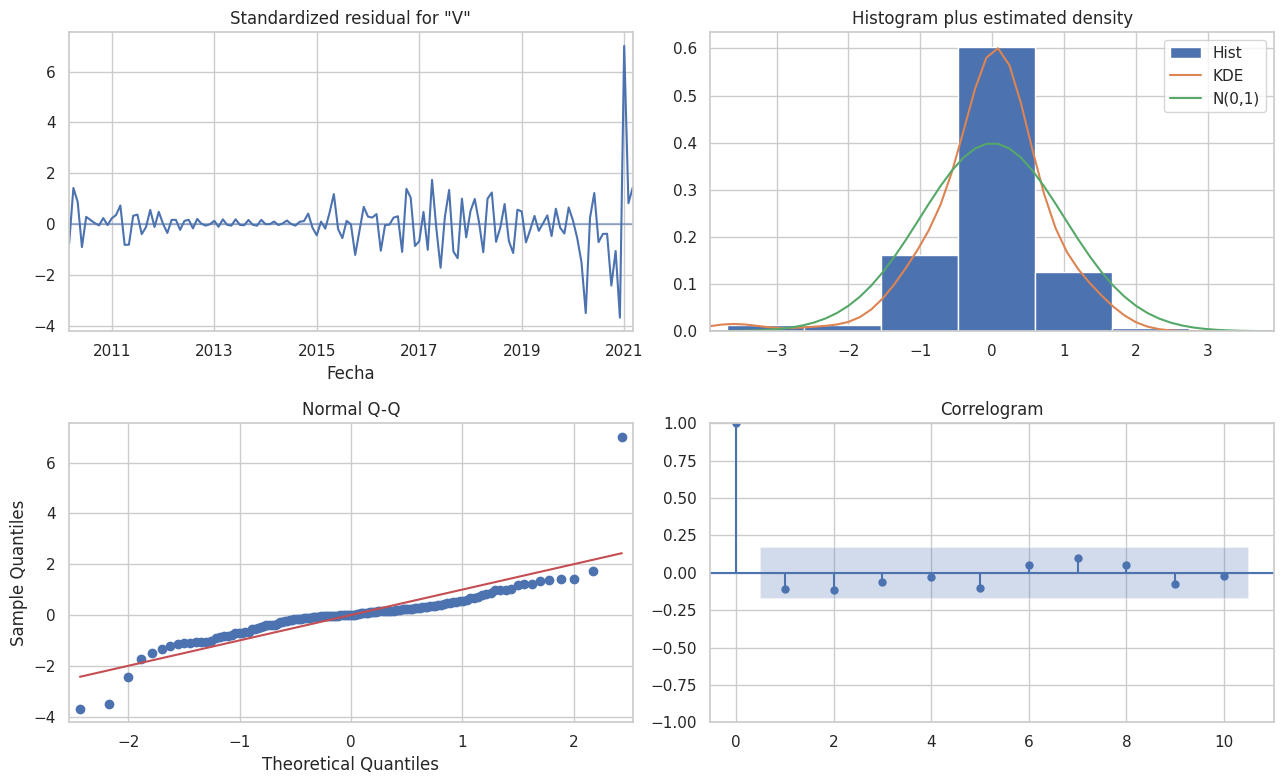

In [35]:
# g) Comparación de los dos modelos por AIC/BIC y análisis de residuos.
comparacion = pd.DataFrame({
    "AIC": [modelo_1_san_cristobal.aic, modelo_2_san_cristobal.aic],
    "BIC": [modelo_1_san_cristobal.bic, modelo_2_san_cristobal.bic],
}, index=["Modelo 1 (ACF/PACF)", "Modelo 2 (búsqueda AIC)"]).round(2)
display(comparacion)

burn = d + s * D
for nombre, modelo in [("Modelo 1", modelo_1_san_cristobal), ("Modelo 2", modelo_2_san_cristobal)]:
    resid = pd.Series(modelo.standardized_forecasts_error[0], index=serie_san_cristobal_log.index).iloc[burn:]
    lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
    print(f"{nombre} — Ljung-Box p-valores: lag 12 = {lb['lb_pvalue'].iloc[0]:.3f}, lag 24 = {lb['lb_pvalue'].iloc[1]:.3f}")

modelo_1_san_cristobal.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()


#### **h. Otros modelos y comparación.**

Gana el suavizamiento exponencial simple (MAE≈21,103, RMSE≈23,740), seguido de cerca por seasonal naive (MAE≈21,408) y Holt-Winters (MAE≈21,992); los SARIMA (MAE≈23,004 y 22,953) y Prophet (MAE≈22,602) quedan atrás, pero con diferencias pequeñas entre todos los modelos. Con un volumen menor y más ruido, ningún modelo saca ventaja clara.

In [36]:
# h) Modelos alternativos sobre el train (log): Holt-Winters, suavizamiento exponencial simple, seasonal naive y Prophet.
serie_test_san_cristobal_log = np.log(prueba[prueba["Frontera"] == "09 San Cristóbal"].groupby("Fecha")["Viajero"].sum().asfreq("MS"))
H_san_cristobal = len(serie_test_san_cristobal_log)

hw_san_cristobal = ExponentialSmoothing(serie_san_cristobal_log, trend="add", seasonal="add", seasonal_periods=s).fit()
ses_san_cristobal = SimpleExpSmoothing(serie_san_cristobal_log).fit()

df_prophet_san_cristobal = pd.DataFrame({"ds": serie_san_cristobal_log.index, "y": serie_san_cristobal_log.values})
modelo_prophet_san_cristobal = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modelo_prophet_san_cristobal.fit(df_prophet_san_cristobal)
pred_prophet_san_cristobal = modelo_prophet_san_cristobal.predict(pd.DataFrame({"ds": serie_test_san_cristobal_log.index})).set_index("ds")["yhat"]

pronosticos_san_cristobal = {
    "SARIMA (Modelo 1)": modelo_1_san_cristobal.get_forecast(H_san_cristobal).predicted_mean,
    "SARIMA (Modelo 2)": modelo_2_san_cristobal.get_forecast(H_san_cristobal).predicted_mean,
    "Holt-Winters": hw_san_cristobal.forecast(H_san_cristobal),
    "Suav. exp. simple": ses_san_cristobal.forecast(H_san_cristobal),
    "Seasonal naive": pd.Series(np.tile(serie_san_cristobal_log.iloc[-s:].values, int(np.ceil(H_san_cristobal / s)))[:H_san_cristobal],
                                 index=serie_test_san_cristobal_log.index),
    "Prophet": pred_prophet_san_cristobal,
}

def metricas(y_true_log, y_pred_log):
    y_true, y_pred = np.exp(y_true_log), np.exp(np.asarray(y_pred_log))
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

tabla_h_san_cristobal = pd.DataFrame(
    {nombre: dict(zip(["MAE", "RMSE"], metricas(serie_test_san_cristobal_log.values, p.values))) for nombre, p in pronosticos_san_cristobal.items()}
).T.round(1).sort_values("RMSE")
display(tabla_h_san_cristobal)


11:38:18 - cmdstanpy - INFO - Chain [1] start processing


11:38:18 - cmdstanpy - INFO - Chain [1] done processing


,MAE,RMSE
Suav. exp. simple,21103.3,23740.3
Seasonal naive,21408.0,24052.5
Holt-Winters,21991.9,24597.1
Prophet,22601.5,25261.8
SARIMA (Modelo 2),22953.1,25460.2
SARIMA (Modelo 1),23003.6,25472.1


#### **i. Predicción con el mejor modelo.**

Con el SES se proyecta hasta 2027. Igual que en La Aurora, se mantiene plano en el nivel deprimido por la pandemia y subestima la recuperación real desde 2022.

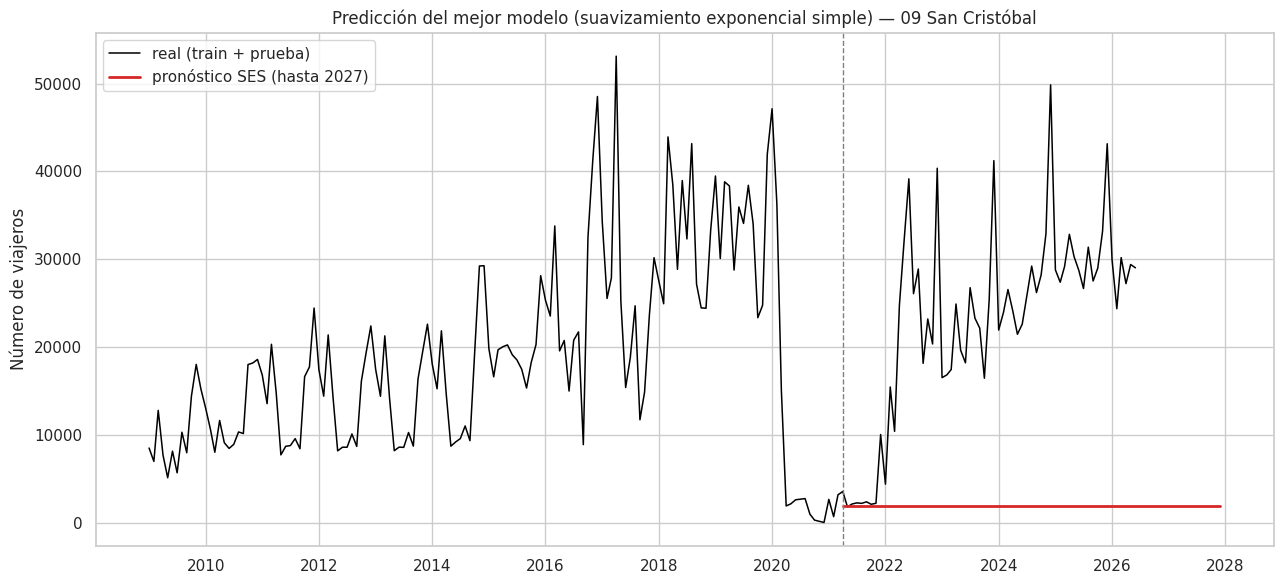

,real,predicho_SES
2021,35092.0,17462.0
2022,283105.0,23283.0
2023,268747.0,23283.0
2024,332799.0,23283.0
2025,368060.0,23283.0
2026,170153.0,23283.0
2027,NaN,23283.0


In [37]:
# i) Predicción con el mejor modelo (suavizamiento exponencial simple), extendida hasta 2027.
serie_real_san_cristobal = pd.concat([np.exp(serie_san_cristobal_log), np.exp(serie_test_san_cristobal_log)])
indice_futuro_san_cristobal = pd.date_range(serie_test_san_cristobal_log.index.min(), "2027-12-01", freq="MS")
pronostico_ses_san_cristobal = np.exp(pd.Series(ses_san_cristobal.forecast(len(indice_futuro_san_cristobal)).values, index=indice_futuro_san_cristobal))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(serie_real_san_cristobal.index, serie_real_san_cristobal.values, color="black", linewidth=1.1, label="real (train + prueba)")
ax.plot(pronostico_ses_san_cristobal.index, pronostico_ses_san_cristobal.values, color="tab:red", linewidth=2, label="pronóstico SES (hasta 2027)")
ax.axvline(serie_test_san_cristobal_log.index.min(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Predicción del mejor modelo (suavizamiento exponencial simple) — 09 San Cristóbal")
ax.set_ylabel("Número de viajeros")
ax.legend()
plt.tight_layout()
plt.show()

totales_anuales_san_cristobal = pd.DataFrame({
    "real": serie_real_san_cristobal.groupby(serie_real_san_cristobal.index.year).sum(),
    "predicho_SES": pronostico_ses_san_cristobal.groupby(pronostico_ses_san_cristobal.index.year).sum(),
}).loc[[2021, 2022, 2023, 2024, 2025, 2026, 2027]].round(0)
display(totales_anuales_san_cristobal)


#### **j. Comparación de modelos por métricas.**

Diferencias pequeñas en MAE/RMSE, con el SES al frente por un margen corto. En AIC/BIC no hay ganador absoluto: el Modelo 1 gana en AIC y el Modelo 2 en BIC.

In [38]:
# j) Tabla 1: MAE y RMSE de todos los modelos.
tabla_errores_san_cristobal = tabla_h_san_cristobal.copy()
display(tabla_errores_san_cristobal)

# j) Tabla 2: AIC y BIC de los dos modelos SARIMA.
tabla_ic_san_cristobal = pd.DataFrame({
    "AIC": [modelo_1_san_cristobal.aic, modelo_2_san_cristobal.aic],
    "BIC": [modelo_1_san_cristobal.bic, modelo_2_san_cristobal.bic],
}, index=["SARIMA (Modelo 1)", "SARIMA (Modelo 2)"]).round(2)
display(tabla_ic_san_cristobal)


,MAE,RMSE
Suav. exp. simple,21103.3,23740.3
Seasonal naive,21408.0,24052.5
Holt-Winters,21991.9,24597.1
Prophet,22601.5,25261.8
SARIMA (Modelo 2),22953.1,25460.2
SARIMA (Modelo 1),23003.6,25472.1


,AIC,BIC
SARIMA (Modelo 1),261.63,278.97
SARIMA (Modelo 2),262.82,274.38


#### **k. Selección del mejor modelo.**

Mejor modelo: suavizamiento exponencial simple (MAE≈21,103, RMSE≈23,740), por un margen pequeño sobre seasonal naive y Holt-Winters. Al ser la frontera con menor volumen y más ruido, ningún modelo logra una ventaja contundente y gana el más simple.